In [291]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline

In [292]:
game_df = pd.read_csv('vgsales.csv')

In [293]:
display(game_df.head())
game_df.drop(columns=['Rank'], inplace=True)
display(game_df.info())
display(game_df.isnull().sum())


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16327 non-null  float64
 3   Genre         16598 non-null  object 
 4   Publisher     16540 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


None

,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


primary questions for data exploration:   
1.   Are there any missing values/outliers?
2.   What is the distribution of each atttribute?
3.   How do game preferences vary by region?
4.   How has the game industry evolved over time?
5.   What are the most successful publisher and platform strategies?  













In [294]:
# Handling the null values in Year and Publisher column
display(game_df.isnull().sum())
game_df.loc[ (game_df['Year'].isnull()) | (game_df['Publisher'].isnull())]

,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...
16427,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01
16493,The Smurfs,3DS,NaN,Action,Unknown,0.00,0.01,0.00,0.00,0.01
16494,Legends of Oz: Dorothy's Return,3DS,2014.0,Puzzle,NaN,0.00,0.01,0.00,0.00,0.01
16543,Driving Simulator 2011,PC,2011.0,Racing,NaN,0.00,0.01,0.00,0.00,0.01


In [295]:
# Use the year mentioned in the game name to replace the null value
game_name_with_year = game_df.loc[ (game_df['Year'].isnull()), "Name"].str.extract(r'.*(\d{4})$')[0].astype('float64')
game_df.loc[(game_df['Year'].isnull()), 'Year'] = game_name_with_year

In [296]:
print(game_df['Year'].isnull().sum())
game_df.iloc[[179, 377, 470, 16543]]

256


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,Madden NFL 2004,PS2,2004.0,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,FIFA Soccer 2004,PS2,2004.0,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
470,wwe Smackdown vs. Raw 2006,PS2,2006.0,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
16543,Driving Simulator 2011,PC,2011.0,Racing,NaN,0.00,0.01,0.00,0.00,0.01


In [297]:
# Calc the missing percentage
print(game_df.shape[0])
print("Missing percentage:", game_df.isnull().sum()/game_df.shape[0])

16598
Missing percentage: Name            0.000000
Platform        0.000000
Year            0.015424
Genre           0.000000
Publisher       0.003494
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
dtype: float64


As it only contains less than 2%, it can be tested whetehr the missing values are MCAR.

In [298]:
missing_cols = ['Year', 'Publisher']
drop_na_game_df = game_df.dropna()
print(len(drop_na_game_df)/len(game_df))

0.9823472707555128


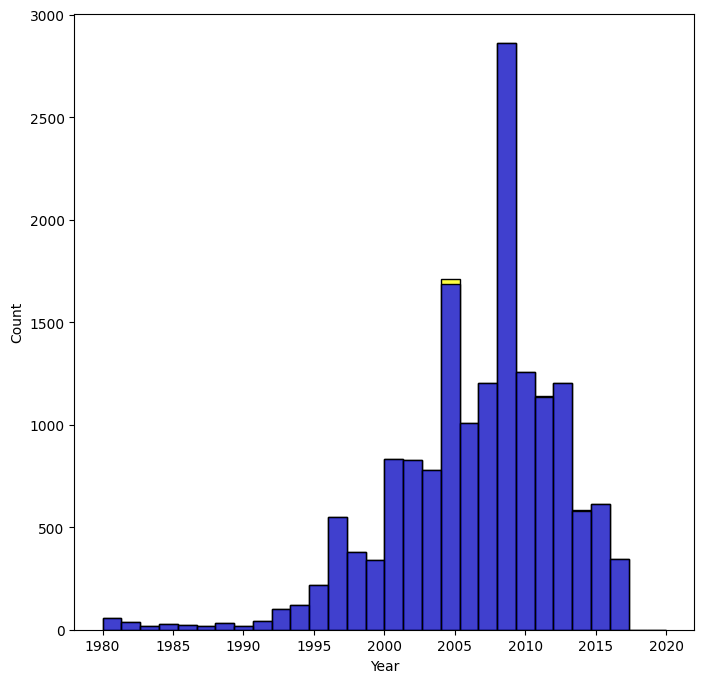

,Original,CCA
Publisher,,
Electronic Arts,0.081395,0.082367
Activision,0.058742,0.059246
Namco Bandai Games,0.056151,0.056915
Ubisoft,0.055489,0.056302
THQ,0.043077,0.043668
Sony Computer Entertainment,0.041150,0.041828


In [299]:
plt.figure(figsize=(8,8))
sns.histplot(game_df['Year'], bins=30, color='yellow')
sns.histplot(drop_na_game_df['Year'], bins=30,  color='blue')
plt.show()
temp = pd.concat([game_df['Publisher'].value_counts()/len(game_df),
drop_na_game_df['Publisher'].value_counts()/len(drop_na_game_df)],
                 axis=1)
temp.columns=['Original', 'CCA']
temp[temp['CCA']-temp['Original']>=0.0005]


In [300]:
game_df_clean = game_df.copy()
game_df_clean.dropna(inplace=True)
display(game_df_clean.describe())
game_df_clean.info()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000
mean,2006.404477,0.265849,0.147823,0.078771,0.048479,0.541193
std,5.830476,0.822699,0.509394,0.311753,0.190111,1.567313
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


<class 'pandas.core.frame.DataFrame'>
Index: 16305 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16305 non-null  object 
 1   Platform      16305 non-null  object 
 2   Year          16305 non-null  float64
 3   Genre         16305 non-null  object 
 4   Publisher     16305 non-null  object 
 5   NA_Sales      16305 non-null  float64
 6   EU_Sales      16305 non-null  float64
 7   JP_Sales      16305 non-null  float64
 8   Other_Sales   16305 non-null  float64
 9   Global_Sales  16305 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.4+ MB


In [301]:
game_df_clean.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


<ipython-input-302-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-302-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-302-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use

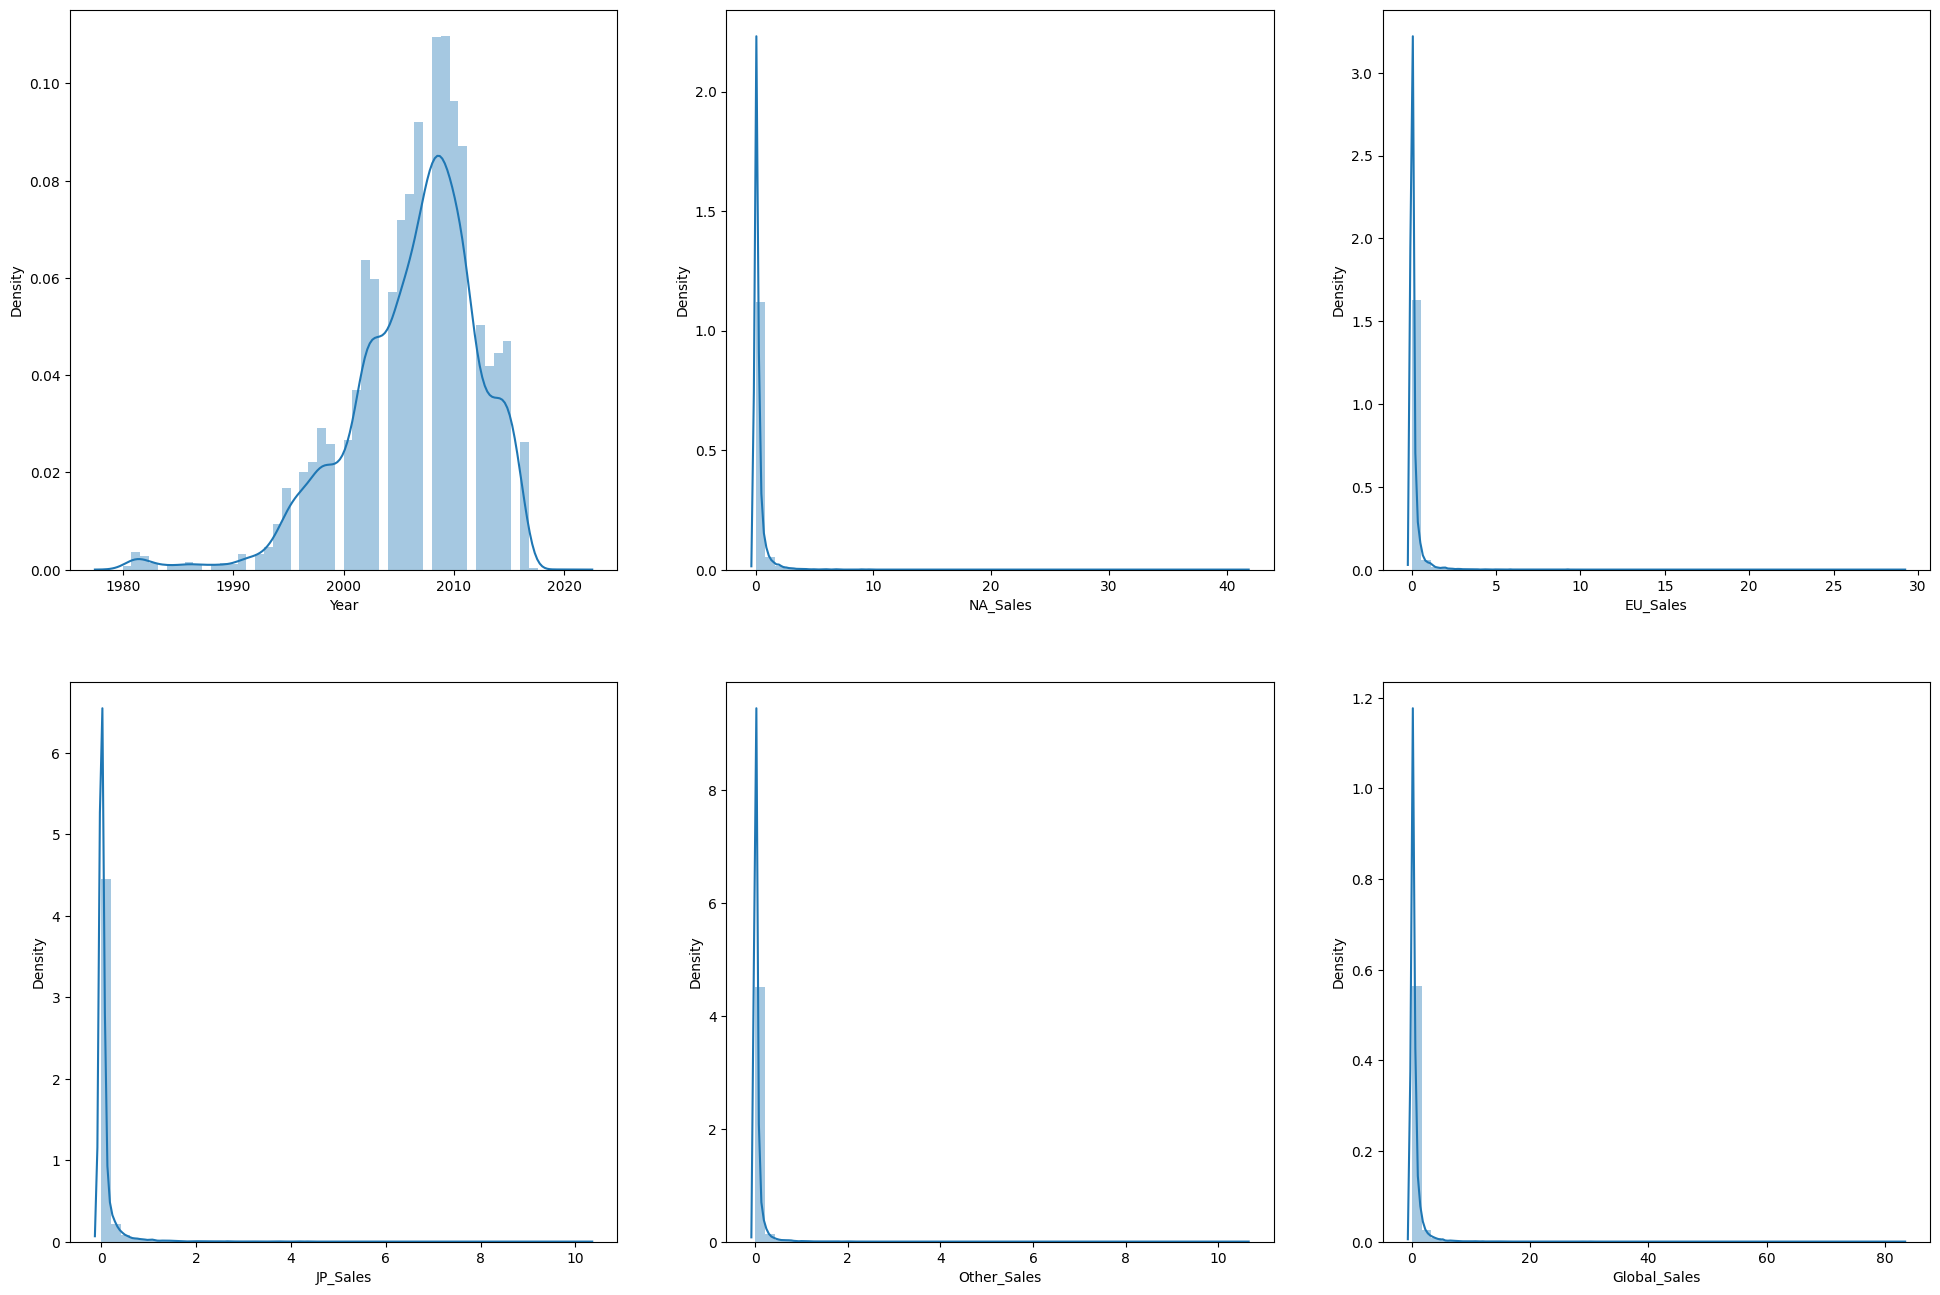

In [302]:
numerical_cols = game_df_clean.select_dtypes(include=['int64','float64']).columns.to_list()
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.distplot(x=game_df_clean[col], ax=ax,)



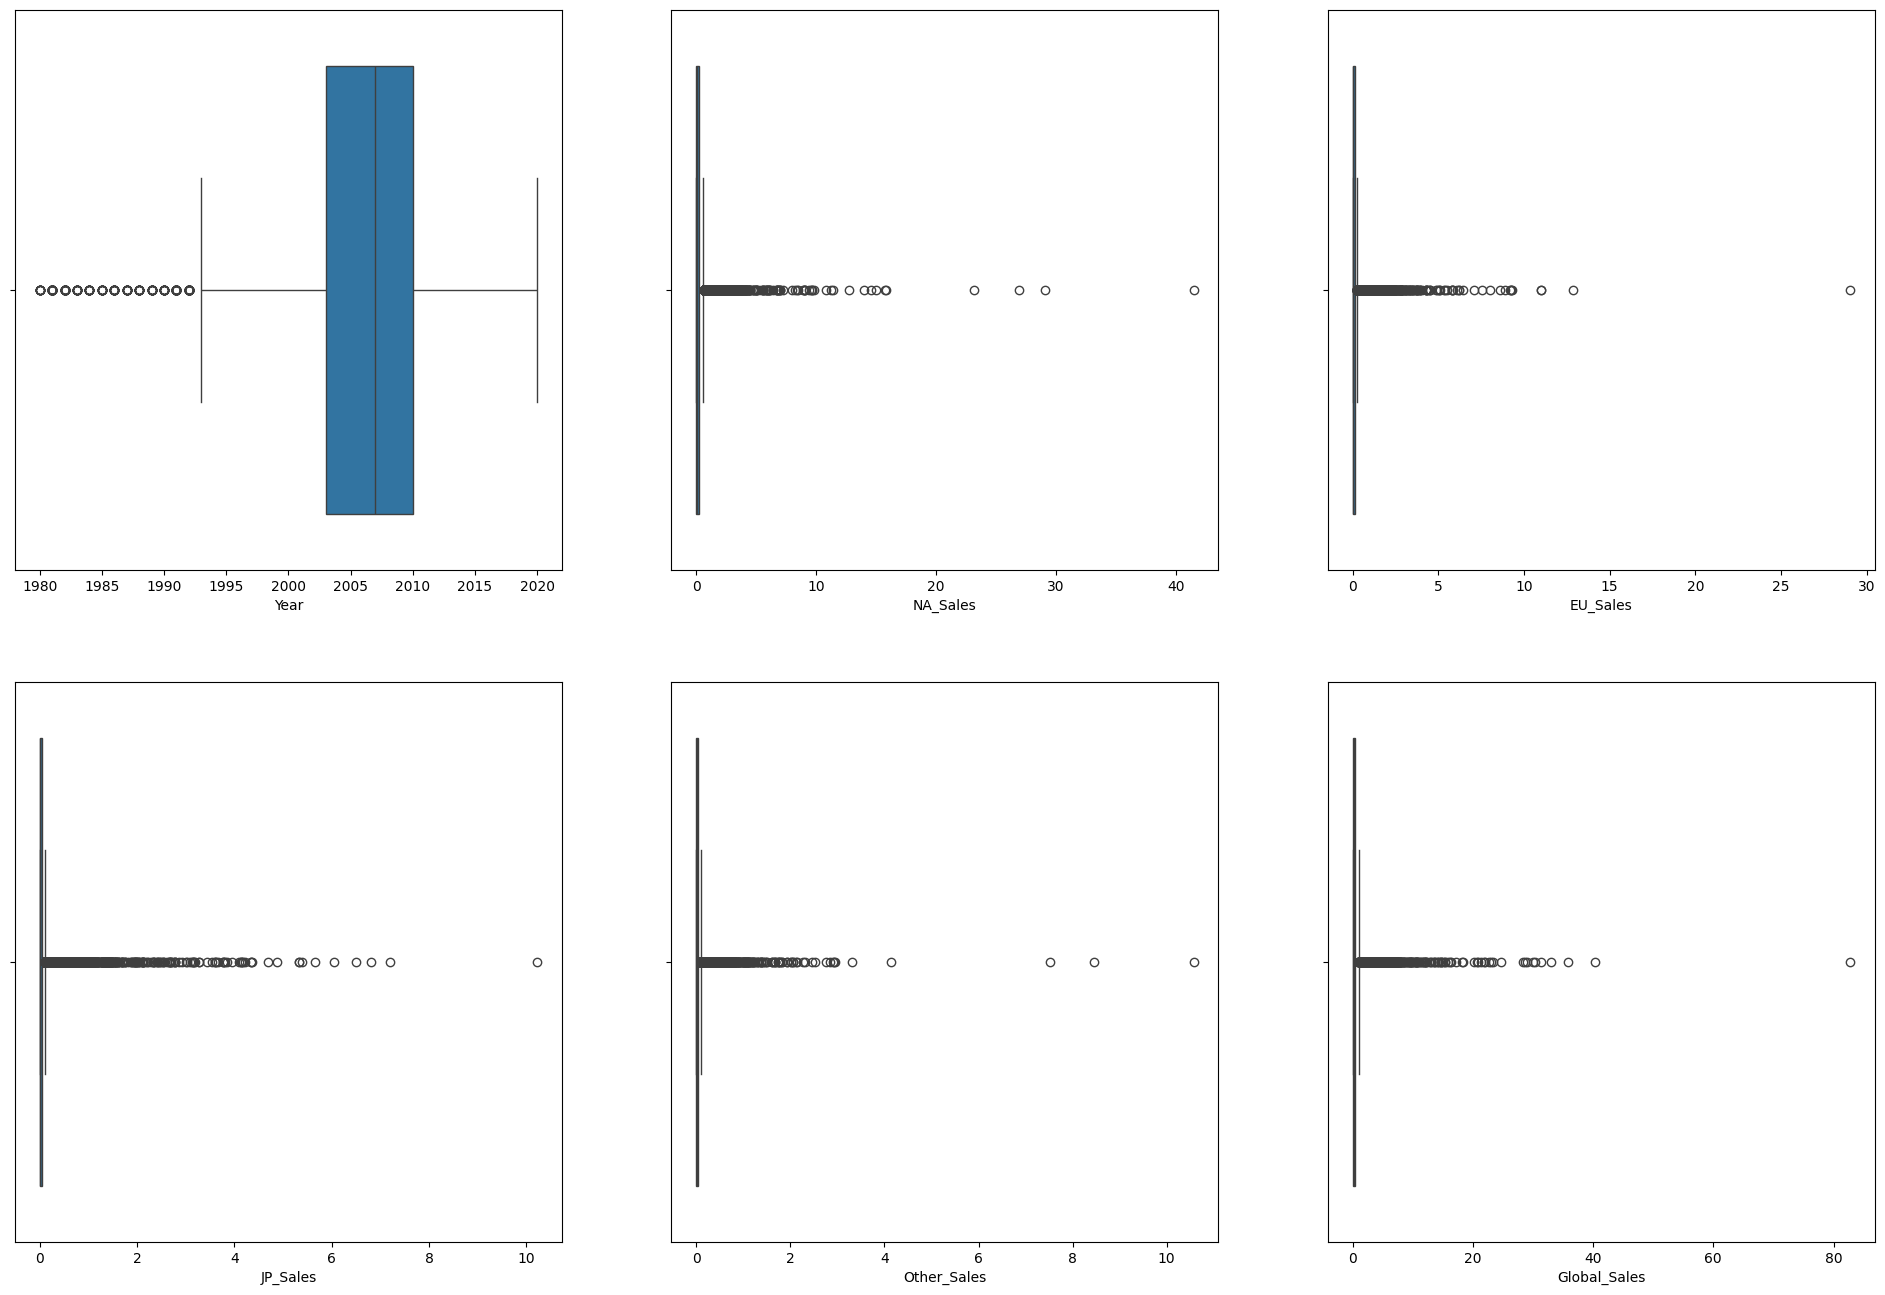

In [303]:
numerical_cols = game_df_clean.select_dtypes(include=['int64','float64']).columns.to_list()
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.boxplot(x=game_df_clean[col], ax=ax,)


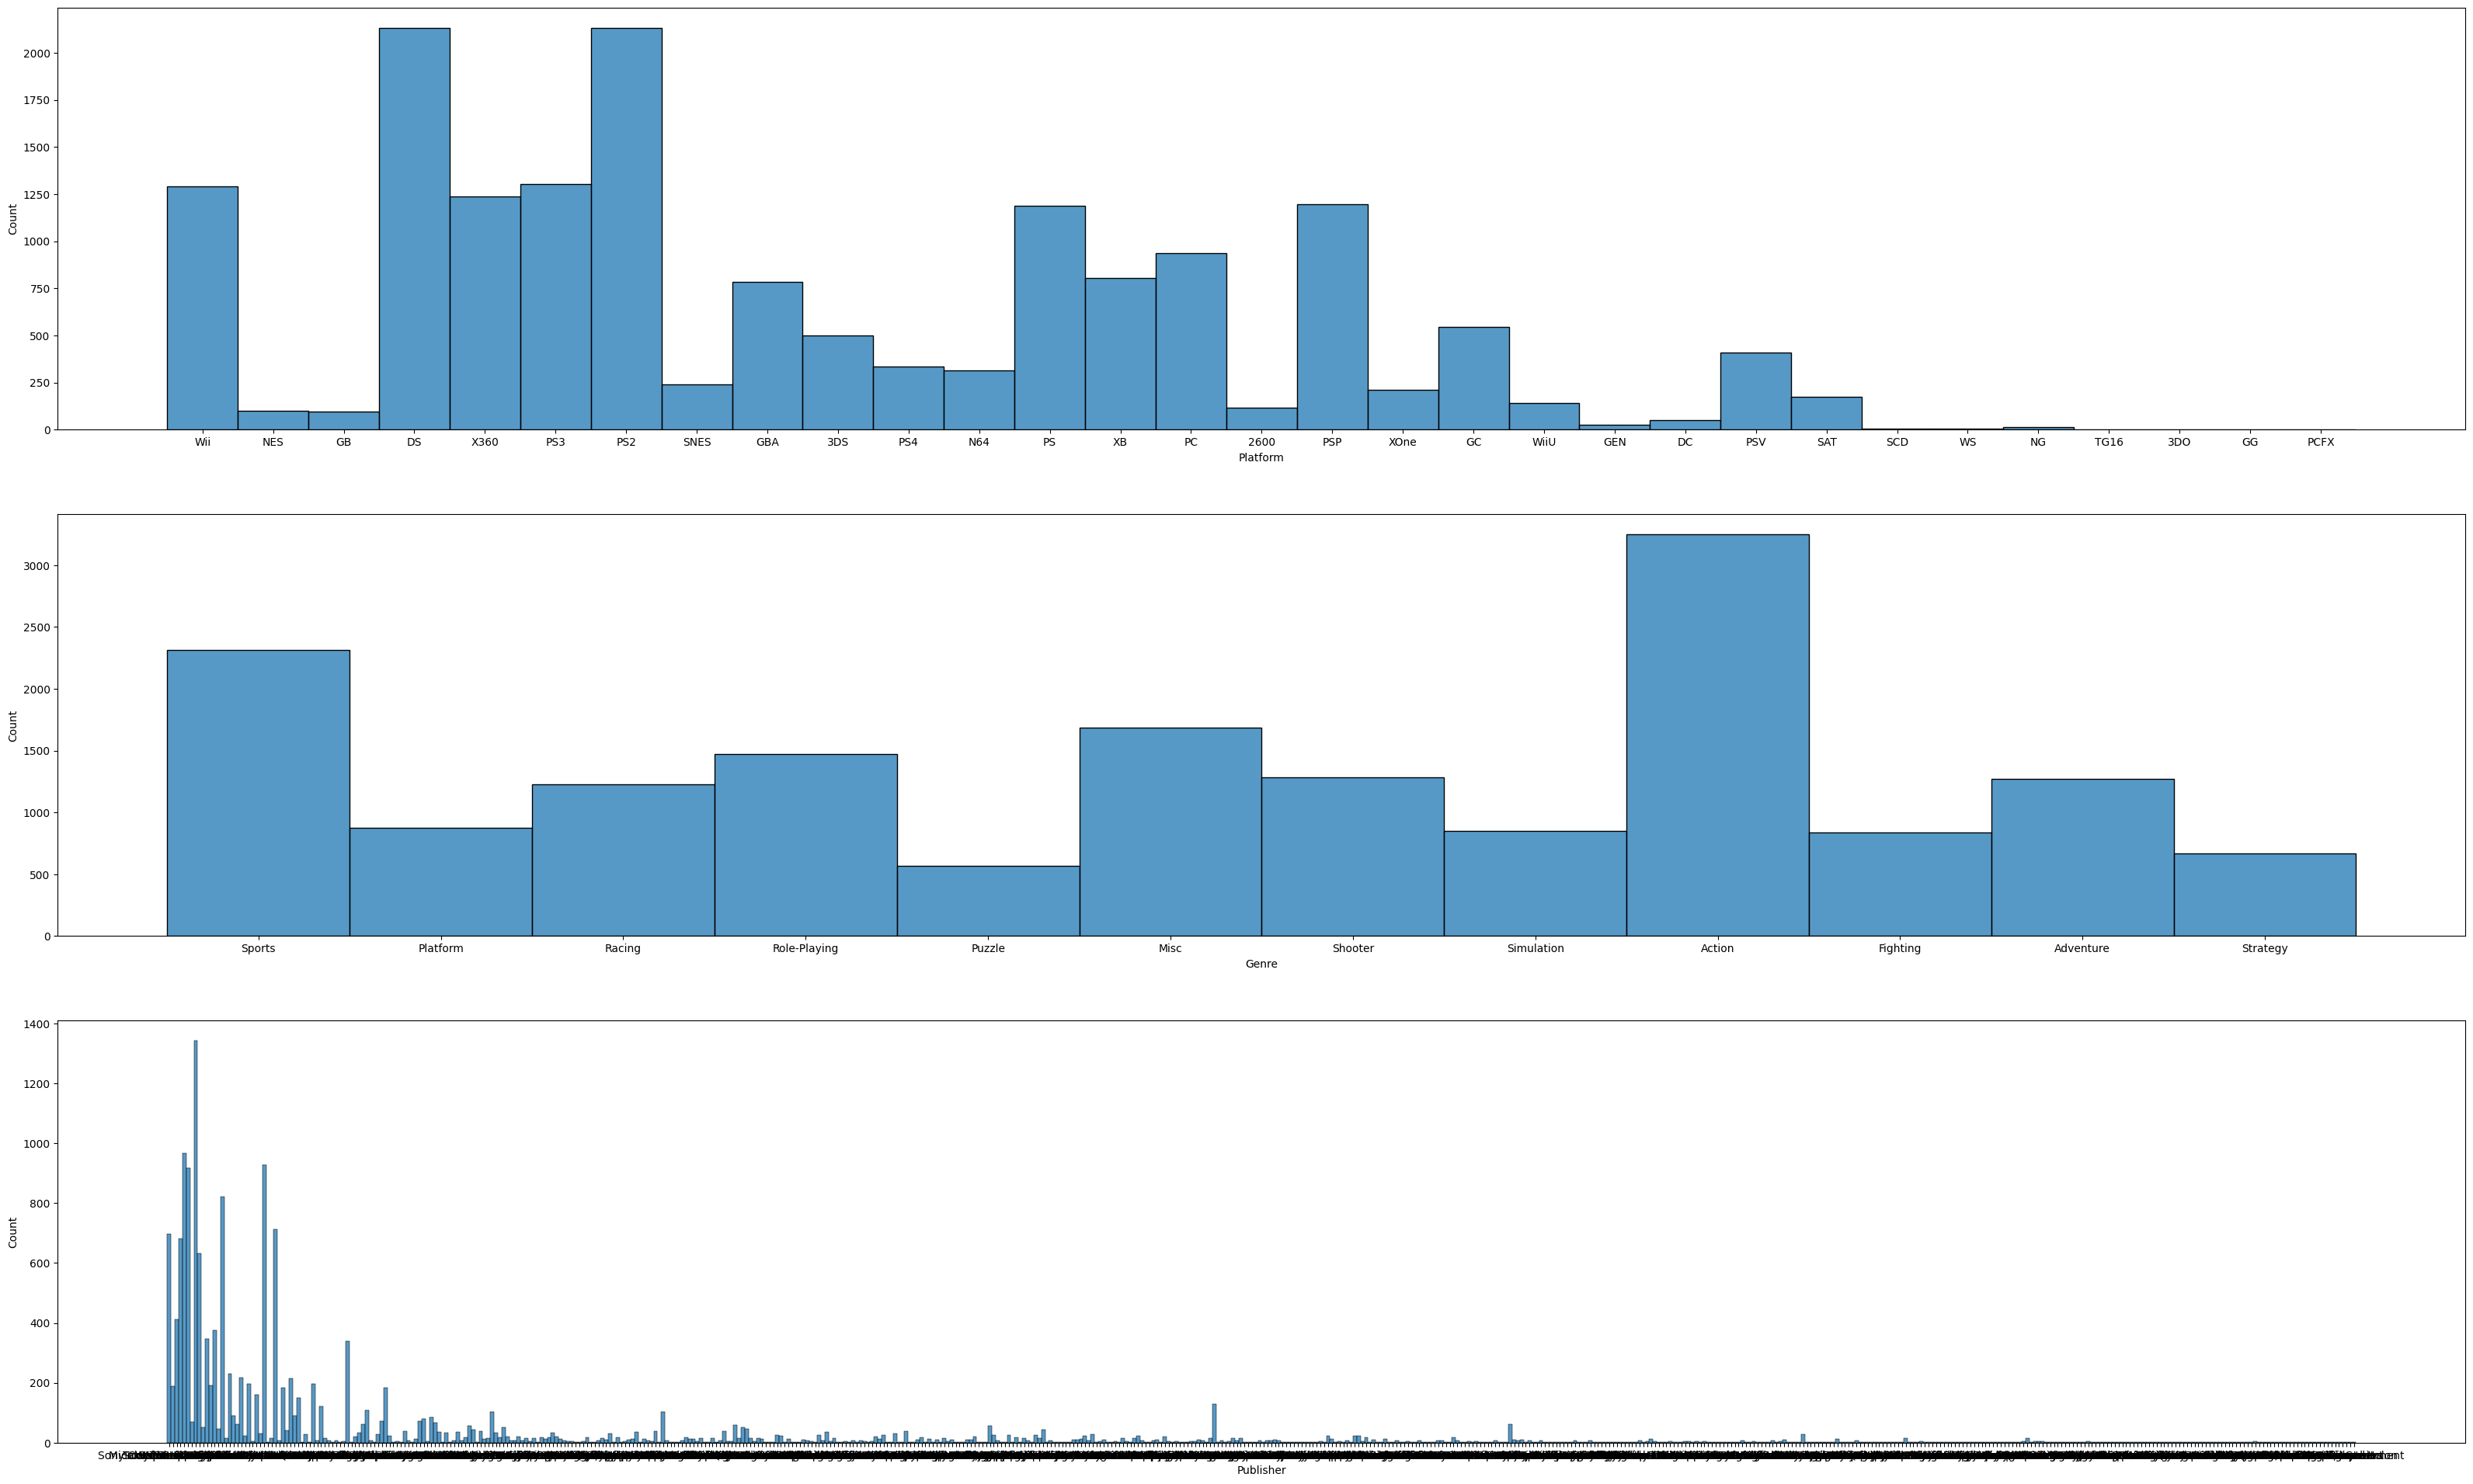

In [304]:
categorical_cols = game_df_clean.select_dtypes(include=['object']).columns.to_list()
categorical_cols.remove('Name')
fig, axes = plt.subplots(3, 1, figsize=(40, 24))
for col, ax in zip(categorical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.histplot(x=game_df_clean[col], ax=ax,)



In [305]:
from sklearn.preprocessing import StandardScaler
standard_scaled_numerical_game_df = StandardScaler().fit_transform(game_df_clean.select_dtypes(include=['int64','float64']).values.tolist())
standard_scaled_numerical_game_df = pd.DataFrame(data=standard_scaled_numerical_game_df, columns=numerical_cols)
display(standard_scaled_numerical_game_df.head())
display(standard_scaled_numerical_game_df.describe())

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,-0.069375,50.109965,56.681170,11.840597,44.246725,52.447300
1,-3.671250,35.025005,6.737969,21.592204,3.795383,25.329993
2,0.273661,18.943296,24.995507,11.904752,17.156424,22.509793
3,0.445178,18.821741,21.324367,10.268792,15.315336,20.710480
4,-1.784554,13.376082,17.162434,32.530684,5.005241,19.670452


,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,1.630500e+04,1.630500e+04,1.630500e+04,1.630500e+04,1.630500e+04,1.630500e+04
mean,4.601859e-16,-2.437591e-14,-6.473282e-14,1.906285e-14,3.730295e-14,-3.397009e-14
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00
min,-4.528839e+00,-3.231518e-01,-2.902021e-01,-2.526787e-01,-2.550118e-01,-3.389303e-01
25%,-5.839286e-01,-3.231518e-01,-2.902021e-01,-2.526787e-01,-2.550118e-01,-3.070276e-01
50%,1.021428e-01,-2.259079e-01,-2.509386e-01,-2.526787e-01,-2.024092e-01,-2.368416e-01
75%,6.166963e-01,-3.142013e-02,-7.425273e-02,-1.243680e-01,-4.460165e-02,-3.904477e-02
max,2.331875e+00,5.010996e+01,5.668117e+01,3.253068e+01,5.534586e+01,5.244730e+01


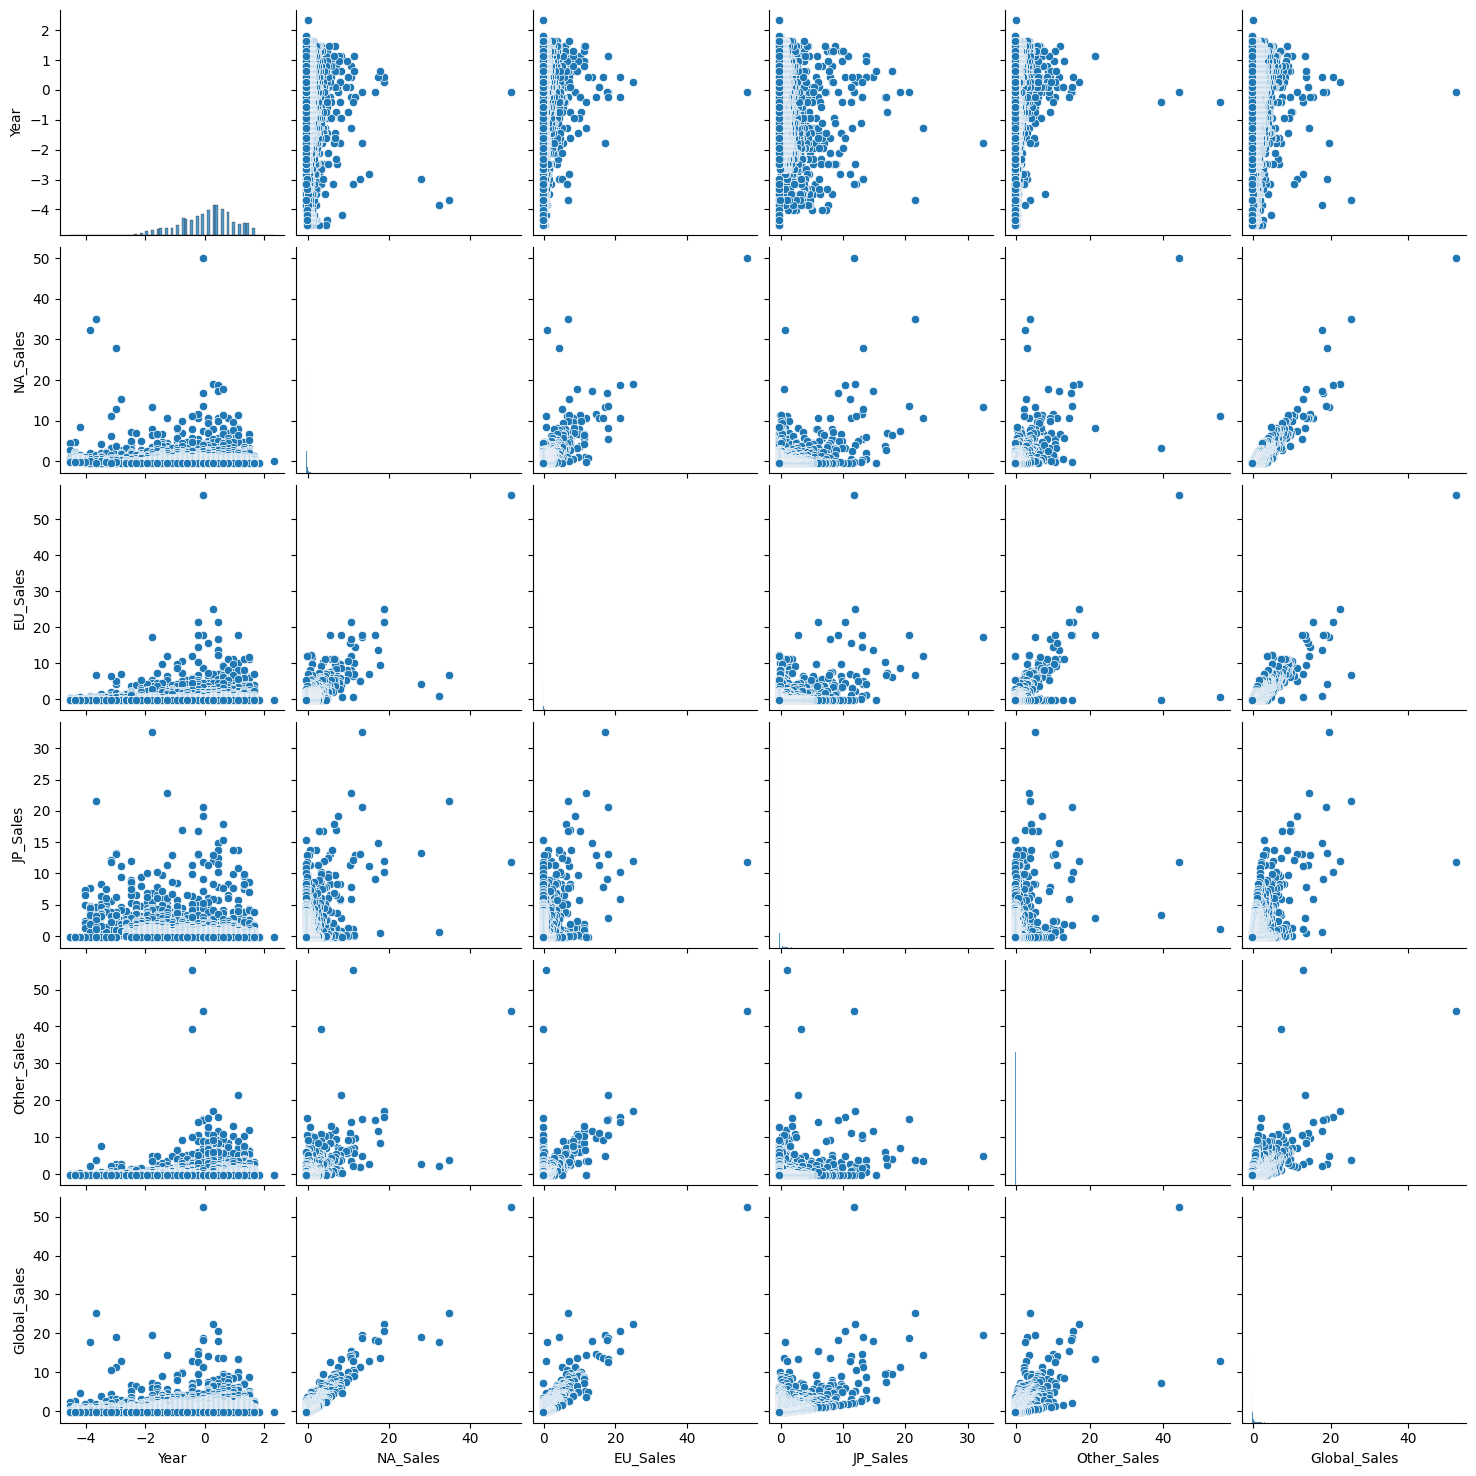

In [306]:
sns.pairplot(standard_scaled_numerical_game_df)

3.   How do game preferences vary by region?

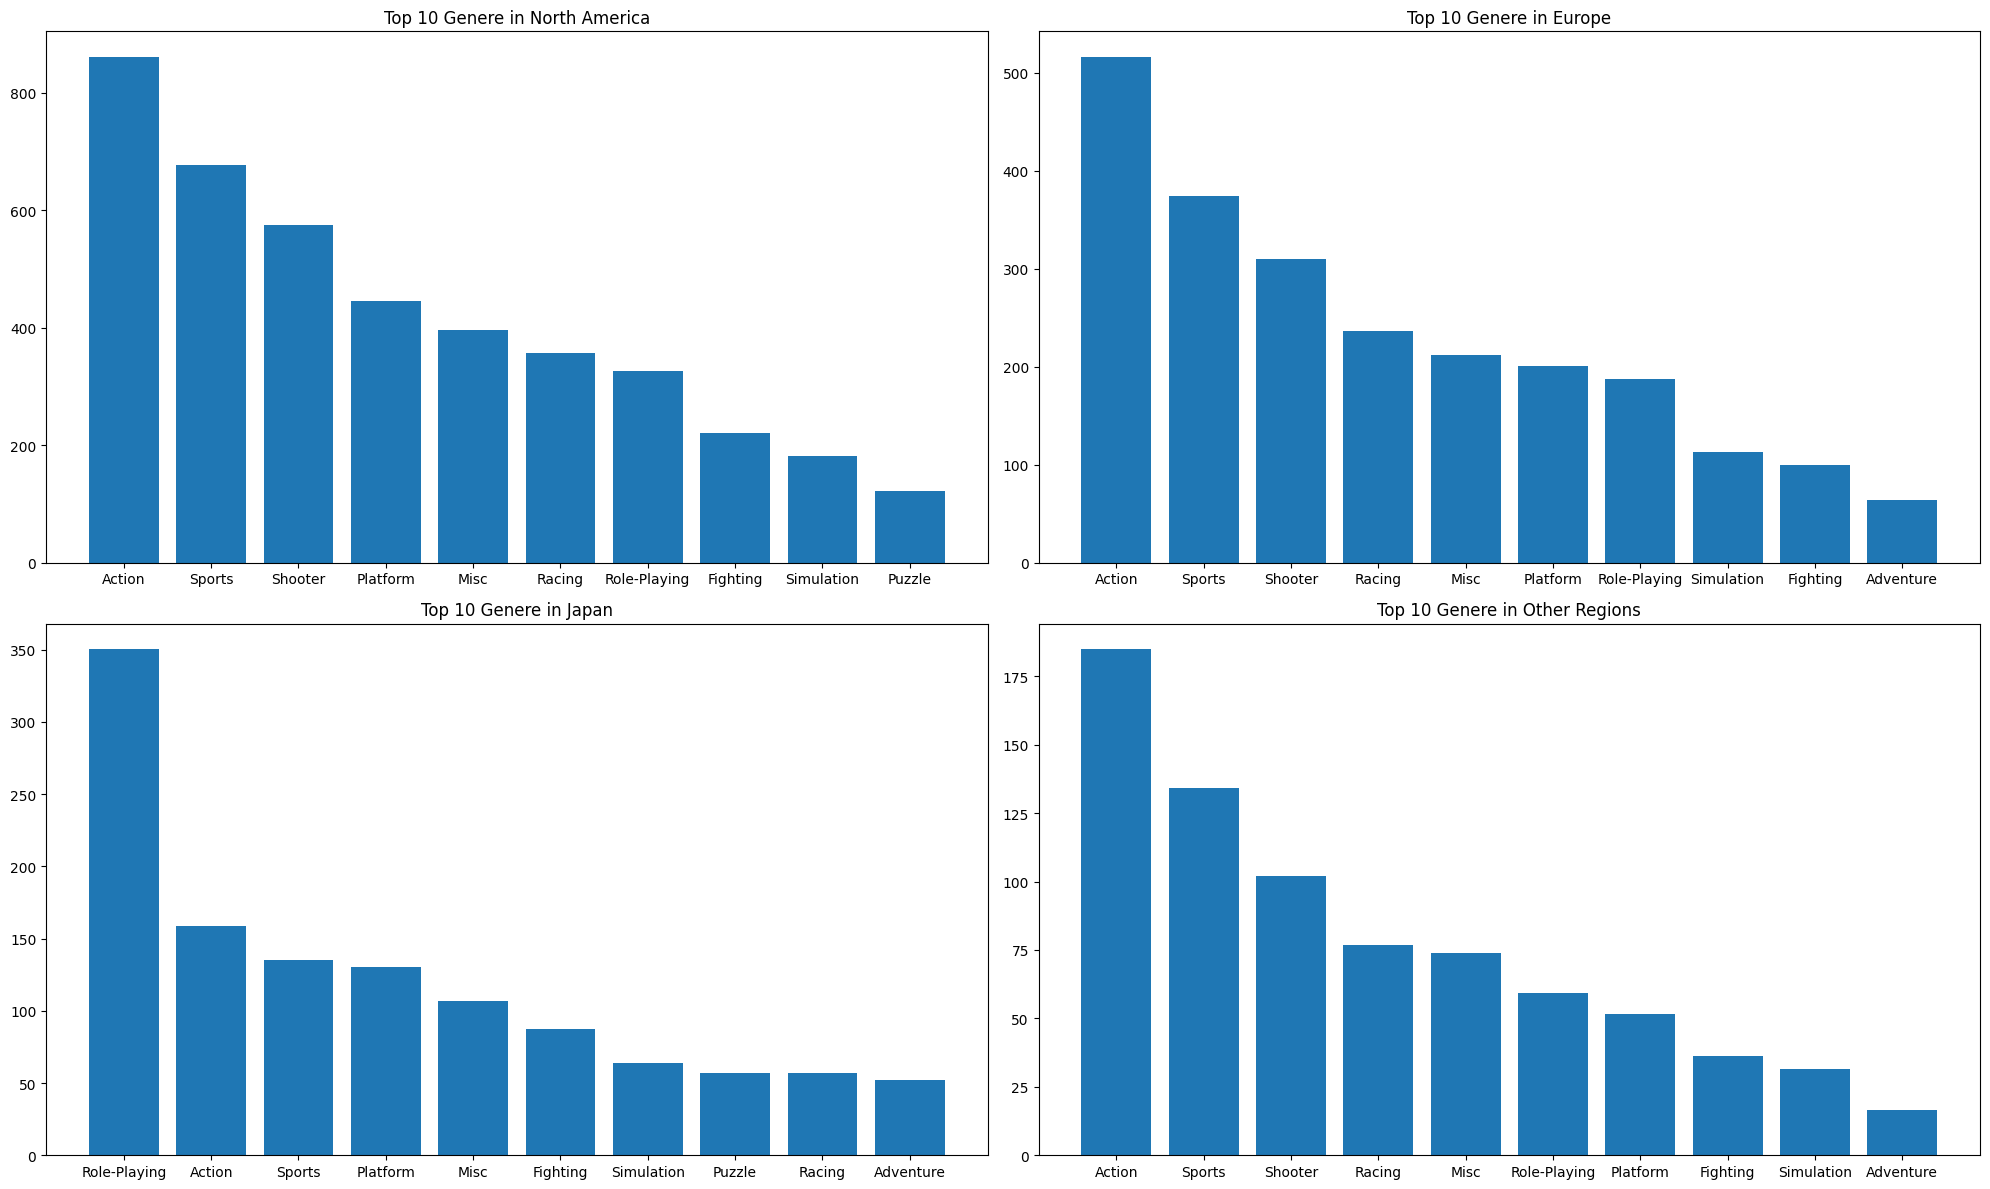

In [307]:
# The top 10 genre in each region (North America, Europe, Japan, Others)
top_10_genre_set=list()
region_names = ['North America', 'Europe', 'Japan', 'Other Regions']
top_10_genre = game_df_clean.groupby('Genre')[['NA_Sales',	'EU_Sales',	'JP_Sales',	'Other_Sales']].sum()
fig, ax_list = plt.subplots(2,2, figsize=(20,12))
ax_list = ax_list.flatten()
for i, ax in enumerate(ax_list):
  top_10_genre_region = top_10_genre[top_10_genre.columns[i]].sort_values(ascending=False)[:10]
  top_10_genre_set.extend(top_10_genre_region.index.to_list())
  ax.bar(x=top_10_genre_region.index, height=top_10_genre_region)
  ax.set_title(f'Top 10 Genere in {region_names[i]}')
plt.tight_layout()
plt.show()
top_10_genre_set = set(top_10_genre_set)

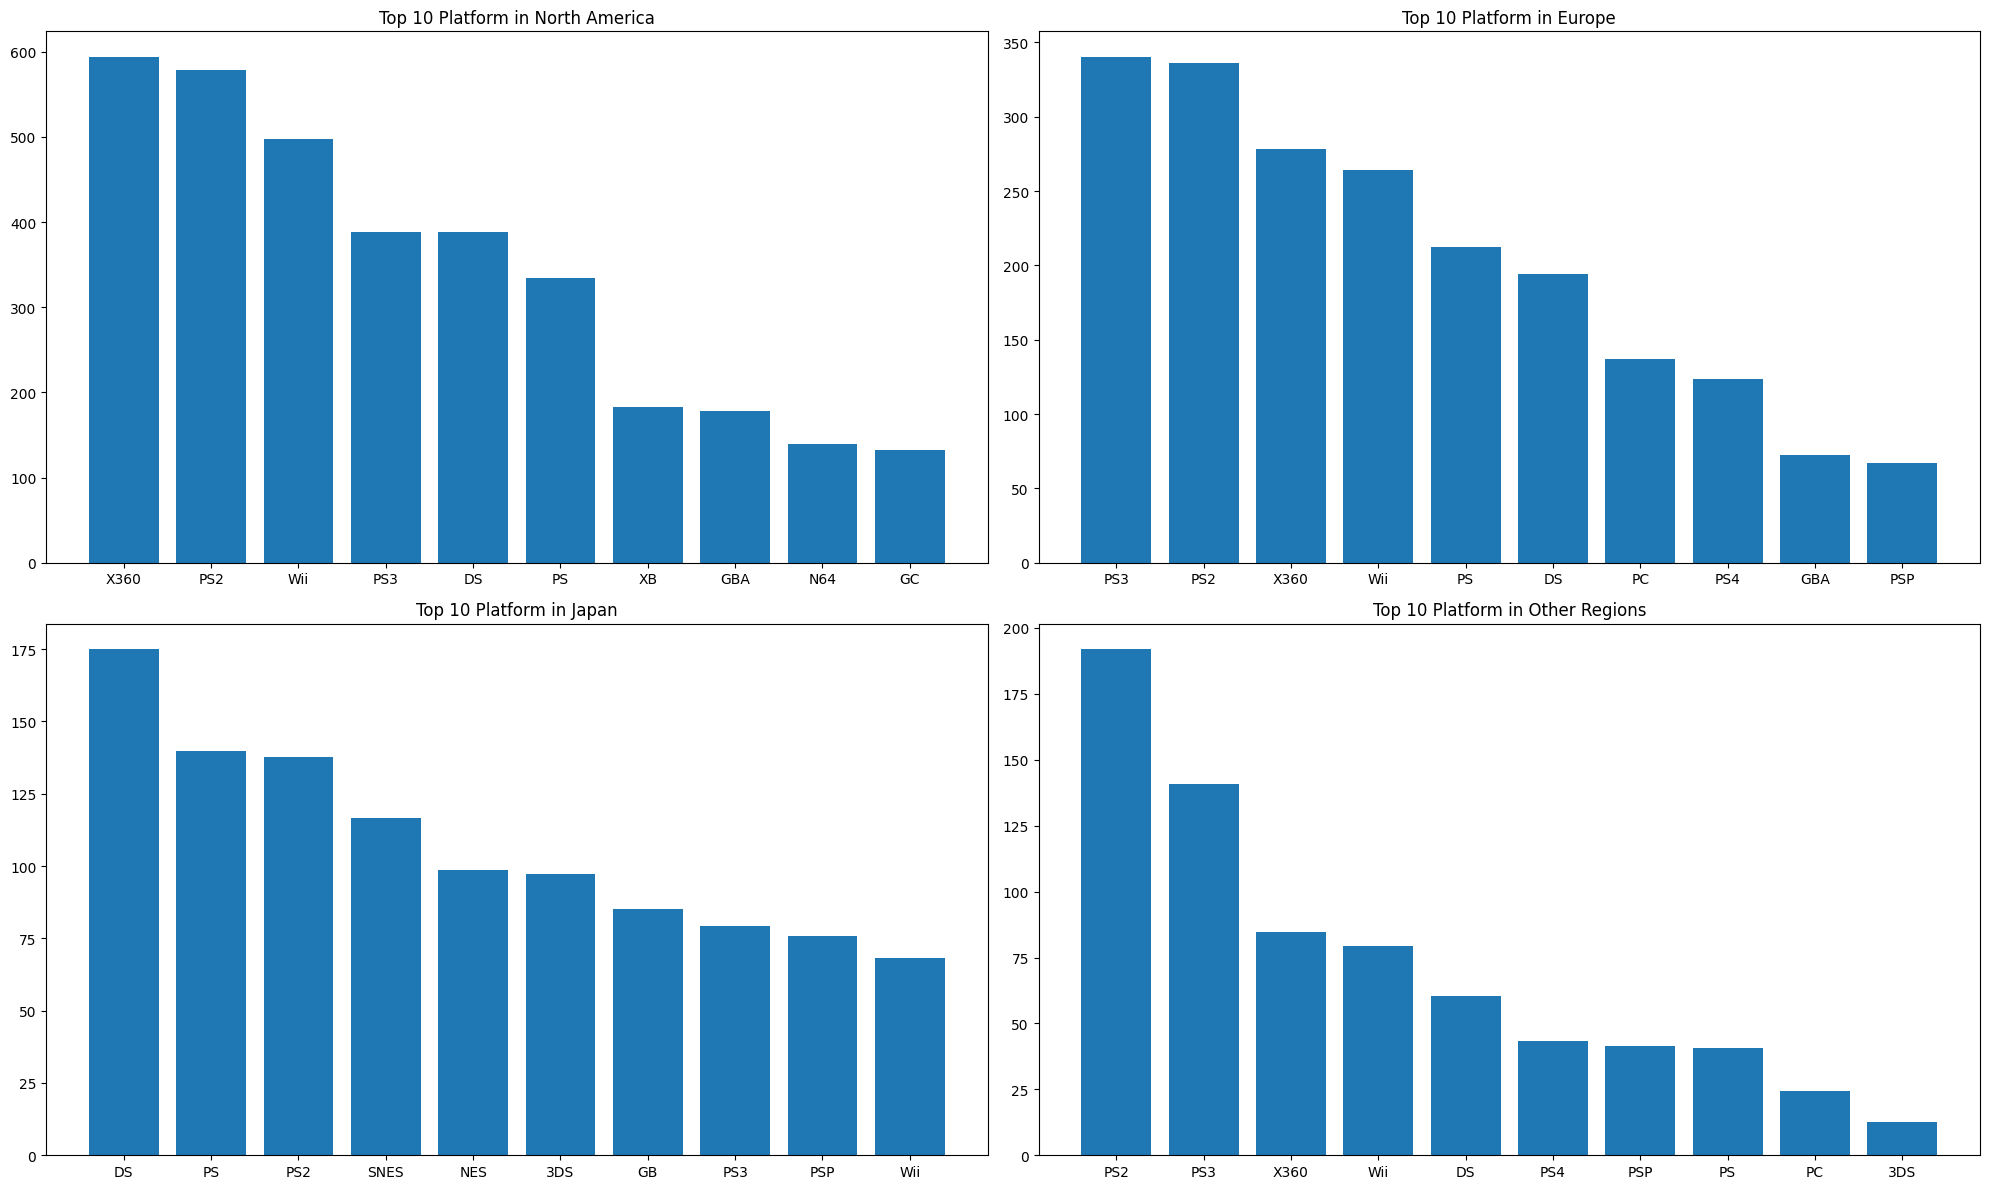

In [308]:
# The top 10 platform in each region (North America, Europe, Japan, Others)
top_10_platform_set = []
region_names = ['North America', 'Europe', 'Japan', 'Other Regions']
top_10_platform = game_df_clean.groupby('Platform')[['NA_Sales',	'EU_Sales',	'JP_Sales',	'Other_Sales']].sum()
fig, ax_list = plt.subplots(2,2, figsize=(20,12))
ax_list = ax_list.flatten()
for i, ax in enumerate(ax_list):
  top_10_platform_region = top_10_platform[top_10_platform.columns[i]].sort_values(ascending=False)[:10]
  top_10_platform_set.extend(top_10_platform_region.index)
  ax.bar(x=top_10_platform_region.index, height=top_10_platform_region)
  ax.set_title(f'Top 10 Platform in {region_names[i]}')
plt.tight_layout()
plt.show()
top_10_platform_set = set(top_10_platform_set)

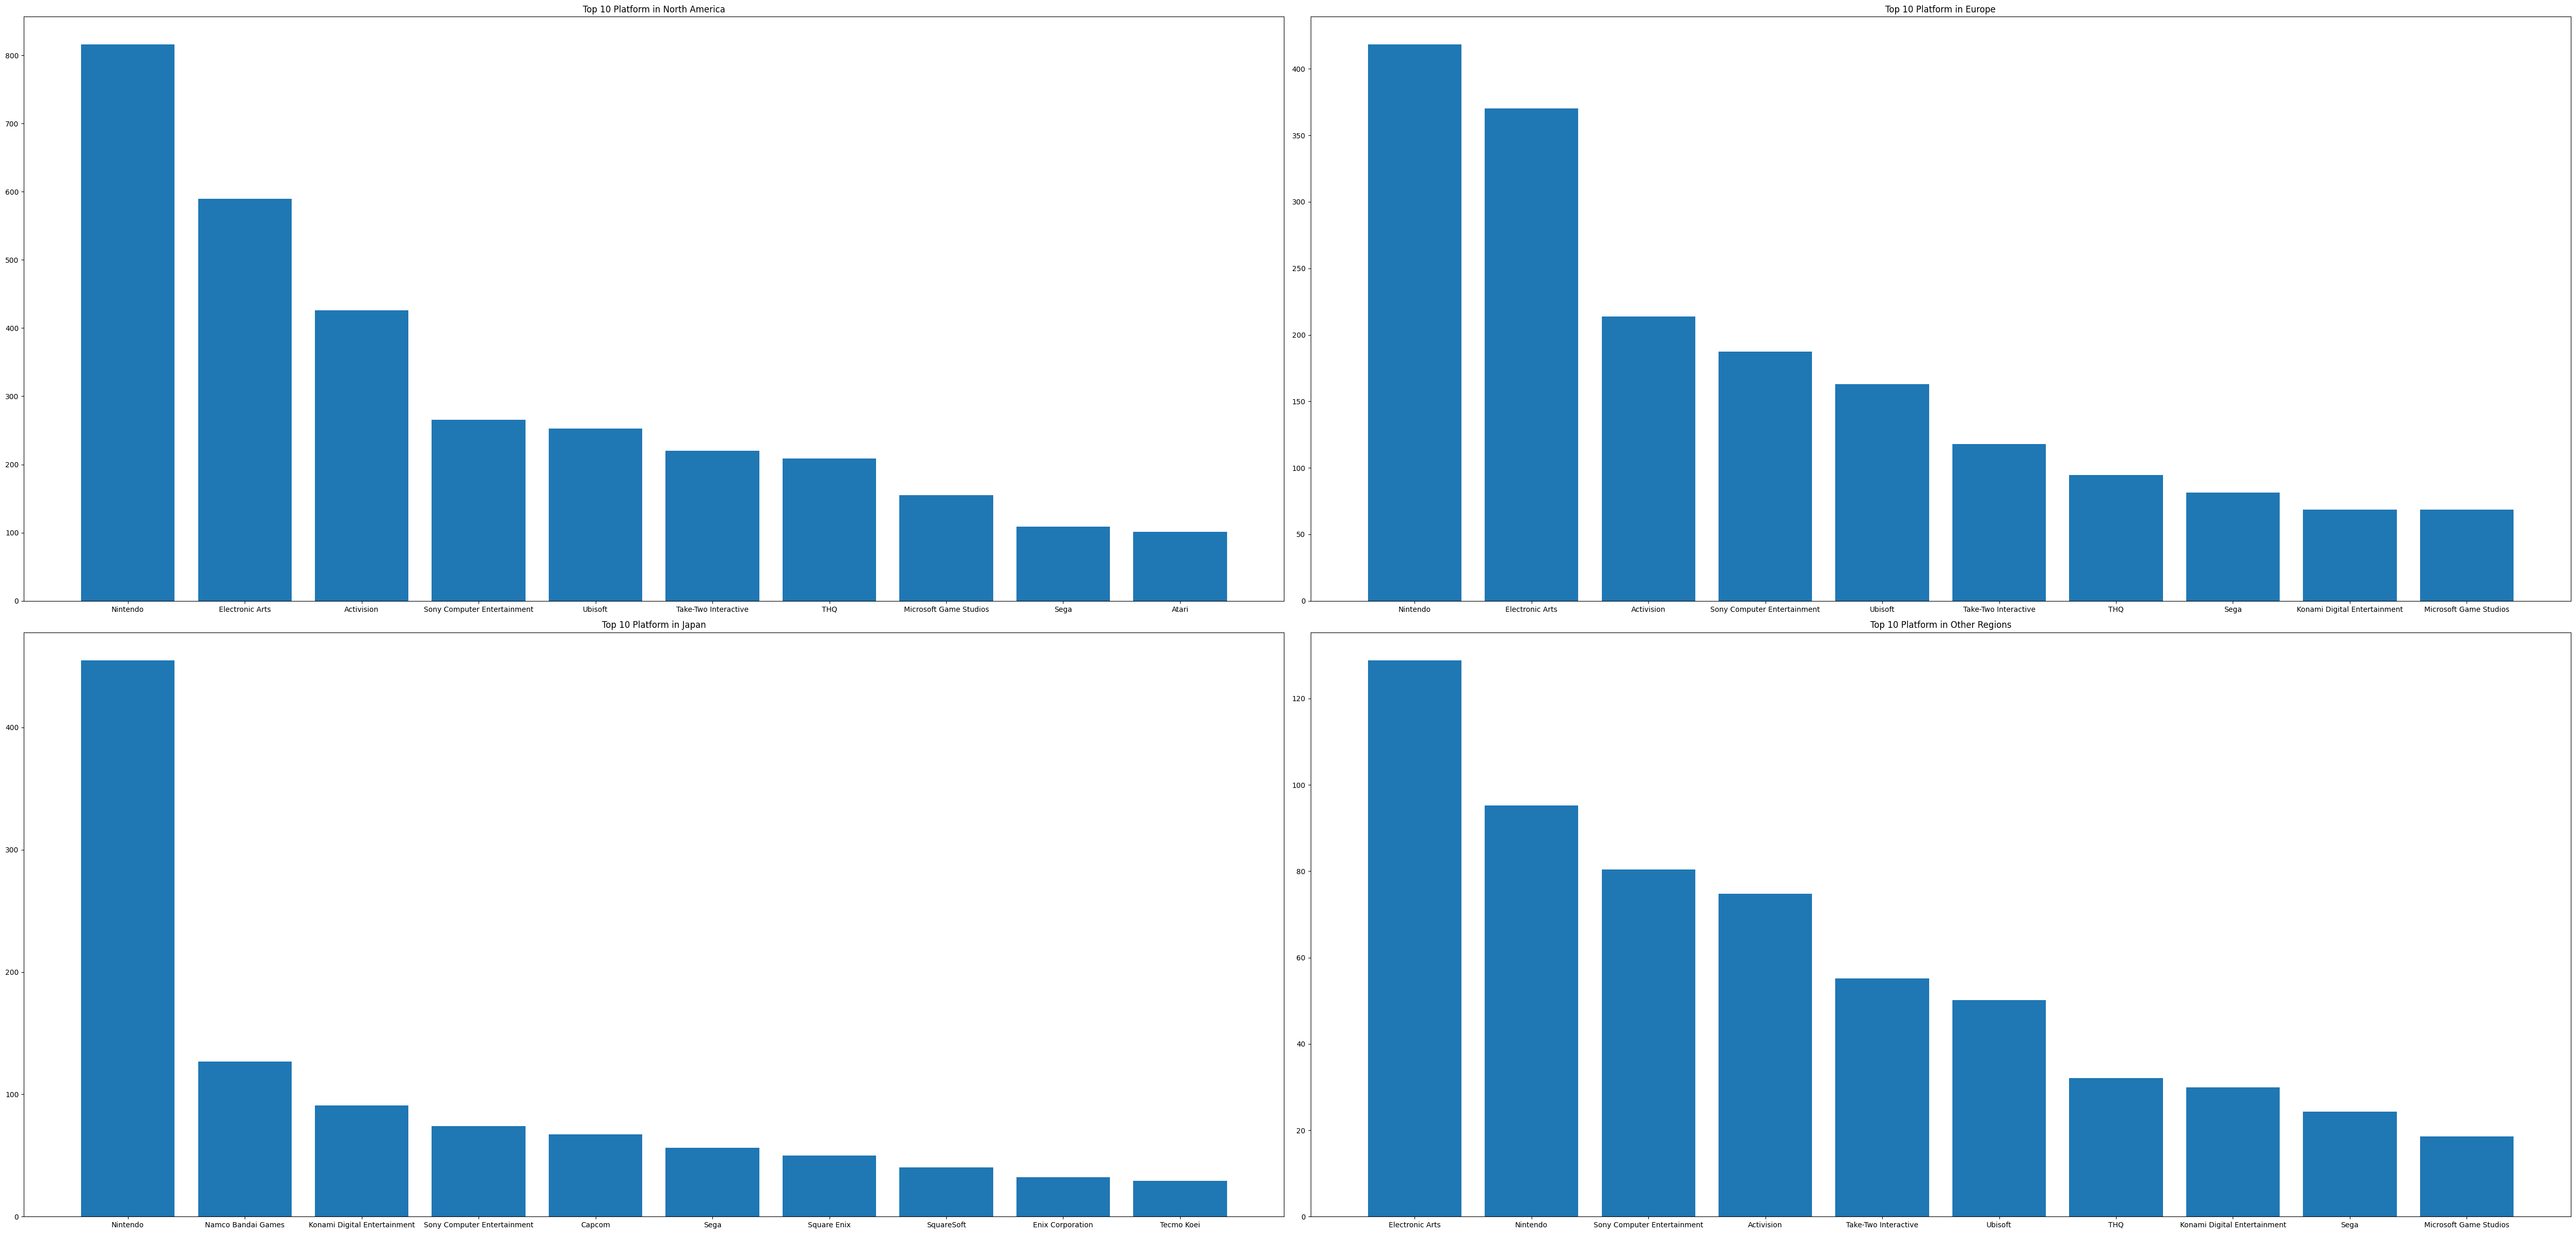

In [309]:
# The top 10 publisher in each region (North America, Europe, Japan, Others)
top_10_publisher_set = []
region_names = ['North America', 'Europe', 'Japan', 'Other Regions']
top_10_publisher = game_df_clean.groupby('Publisher')[['NA_Sales',	'EU_Sales',	'JP_Sales',	'Other_Sales']].sum()
fig, ax_list = plt.subplots(2,2, figsize=(50,24))
ax_list = ax_list.flatten()
for i, ax in enumerate(ax_list):
  top_10_publisher_region = top_10_publisher[top_10_publisher.columns[i]].sort_values(ascending=False)[:10]
  top_10_publisher_set.extend(top_10_publisher.index)
  ax.bar(x=top_10_publisher_region.index, height=top_10_publisher_region)
  ax.set_title(f'Top 10 Platform in {region_names[i]}')
plt.tight_layout()
plt.show()
top_10_publisher_set = set(top_10_publisher_set)

4.   How has the game industry evolved over time?

In [310]:
region_year_trend = game_df_clean.groupby('Year')[['NA_Sales',	'EU_Sales',	'JP_Sales',	'Other_Sales', 'Global_Sales']].sum()
region_year_trend = region_year_trend.stack().reset_index().rename(columns={0: 'Sales', 'level_1': 'Region'})
region_year_trend['Region'] = region_year_trend['Region'].str.replace('_Sales', '')
display(region_year_trend)
fig = px.line(data_frame=region_year_trend, x='Year', y='Sales', color='Region')
fig.update_traces(mode='markers+lines')
fig.show()

,Year,Region,Sales
0,1980.0,NA,10.59
1,1980.0,EU,0.67
2,1980.0,JP,0.00
3,1980.0,Other,0.12
4,1980.0,Global,11.38
...,...,...,...
190,2020.0,NA,0.27
191,2020.0,EU,0.00
192,2020.0,JP,0.00
193,2020.0,Other,0.02


In [311]:
year_genre_trend = game_df_clean.groupby(['Year', 'Genre'])['Global_Sales'].sum()
year_genre_trend = year_genre_trend.reset_index()
top_10_year_genre_trend = year_genre_trend[year_genre_trend['Genre'].isin(top_10_genre_set)]
display(top_10_year_genre_trend)
px.bar(data_frame=top_10_year_genre_trend, x='Genre', y='Global_Sales', animation_frame='Year')

,Year,Genre,Global_Sales
0,1980.0,Action,0.34
1,1980.0,Fighting,0.77
2,1980.0,Misc,2.71
3,1980.0,Shooter,7.07
4,1980.0,Sports,0.49
...,...,...,...
383,2016.0,Simulation,0.39
384,2016.0,Sports,14.60
386,2017.0,Action,0.01
387,2017.0,Role-Playing,0.04


In [312]:
year_platform_trend = game_df_clean.groupby(['Year', 'Platform'])['Global_Sales'].sum()
year_platform_trend = year_platform_trend.reset_index()
top_10_year_platform_trend = year_platform_trend[year_platform_trend['Platform'].isin(top_10_platform_set)]
display(top_10_year_platform_trend)
px.bar(data_frame=top_10_year_platform_trend, x='Platform', y='Global_Sales', animation_frame='Year')

,Year,Platform,Global_Sales
4,1983.0,NES,10.96
6,1984.0,NES,50.09
8,1985.0,DS,0.02
9,1985.0,NES,53.44
10,1985.0,PC,0.03
...,...,...,...
232,2016.0,PS3,2.59
233,2016.0,PS4,39.25
236,2016.0,X360,0.83
238,2017.0,PS4,0.03


In [313]:
year_publisher_trend = game_df_clean.groupby(['Year', 'Publisher'])['Global_Sales'].sum()
year_publisher_trend = year_publisher_trend.reset_index()
top_10_year_publisher_trend = year_publisher_trend[year_publisher_trend['Publisher'].isin(top_10_publisher_set)]
display(top_10_year_publisher_trend)
px.bar(data_frame=top_10_year_publisher_trend, x='Publisher', y='Global_Sales', animation_frame='Year')

,Year,Publisher,Global_Sales
0,1980.0,Activision,3.02
1,1980.0,Atari,8.36
2,1981.0,20th Century Fox Video Games,1.35
3,1981.0,Activision,8.50
4,1981.0,Atari,8.45
...,...,...,...
2316,2016.0,Yeti,0.02
2317,2016.0,dramatic create,0.03
2318,2017.0,Idea Factory,0.01
2319,2017.0,Sega,0.04


5. What are the most successful publisher and platform strategies?

<ipython-input-314-a3f16783efc0>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



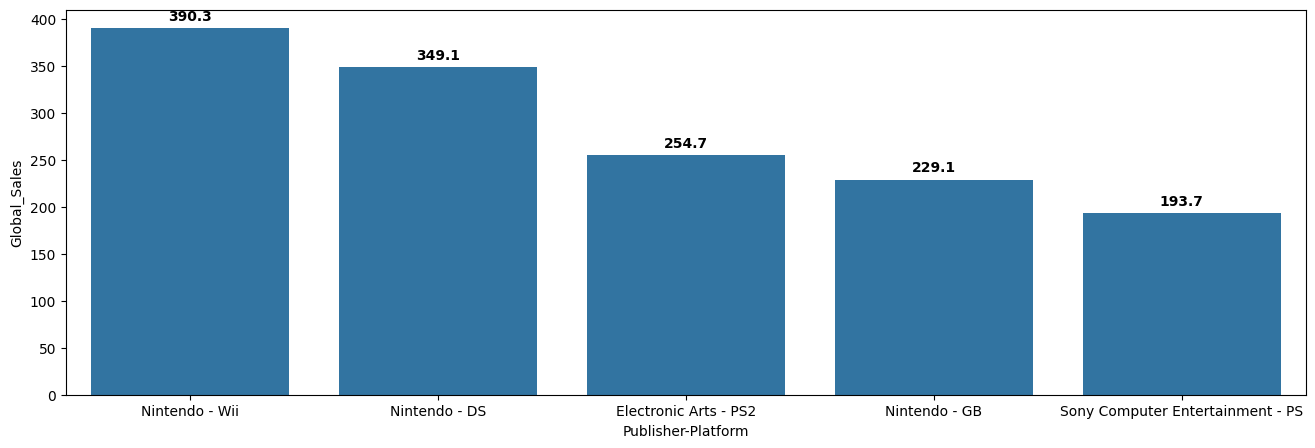

In [314]:
game_platform_publisher_df = game_df_clean.groupby(['Publisher', 'Platform'])['Global_Sales'].sum()
game_platform_publisher_df = game_platform_publisher_df.reset_index().sort_values(by='Global_Sales', ascending=False)
game_platform_publisher_df_top_5 = game_platform_publisher_df.head()
game_platform_publisher_df_top_5['Publisher-Platform'] = game_platform_publisher_df_top_5['Publisher'].str.cat(game_platform_publisher_df_top_5['Platform'], sep=' - ')

plt.figure(figsize=(16, 5))
ax = sns.barplot(data=game_platform_publisher_df_top_5, x='Publisher-Platform', y='Global_Sales', )
for i, v in enumerate(game_platform_publisher_df_top_5['Global_Sales']):
    ax.text(i, v + 5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')


Further Cleaning the Dataset (Treating outliers, skewed distribution, encoding categorical variables, scaling down the data, etc.)

<ipython-input-315-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-315-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-315-587342c97ccc>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use

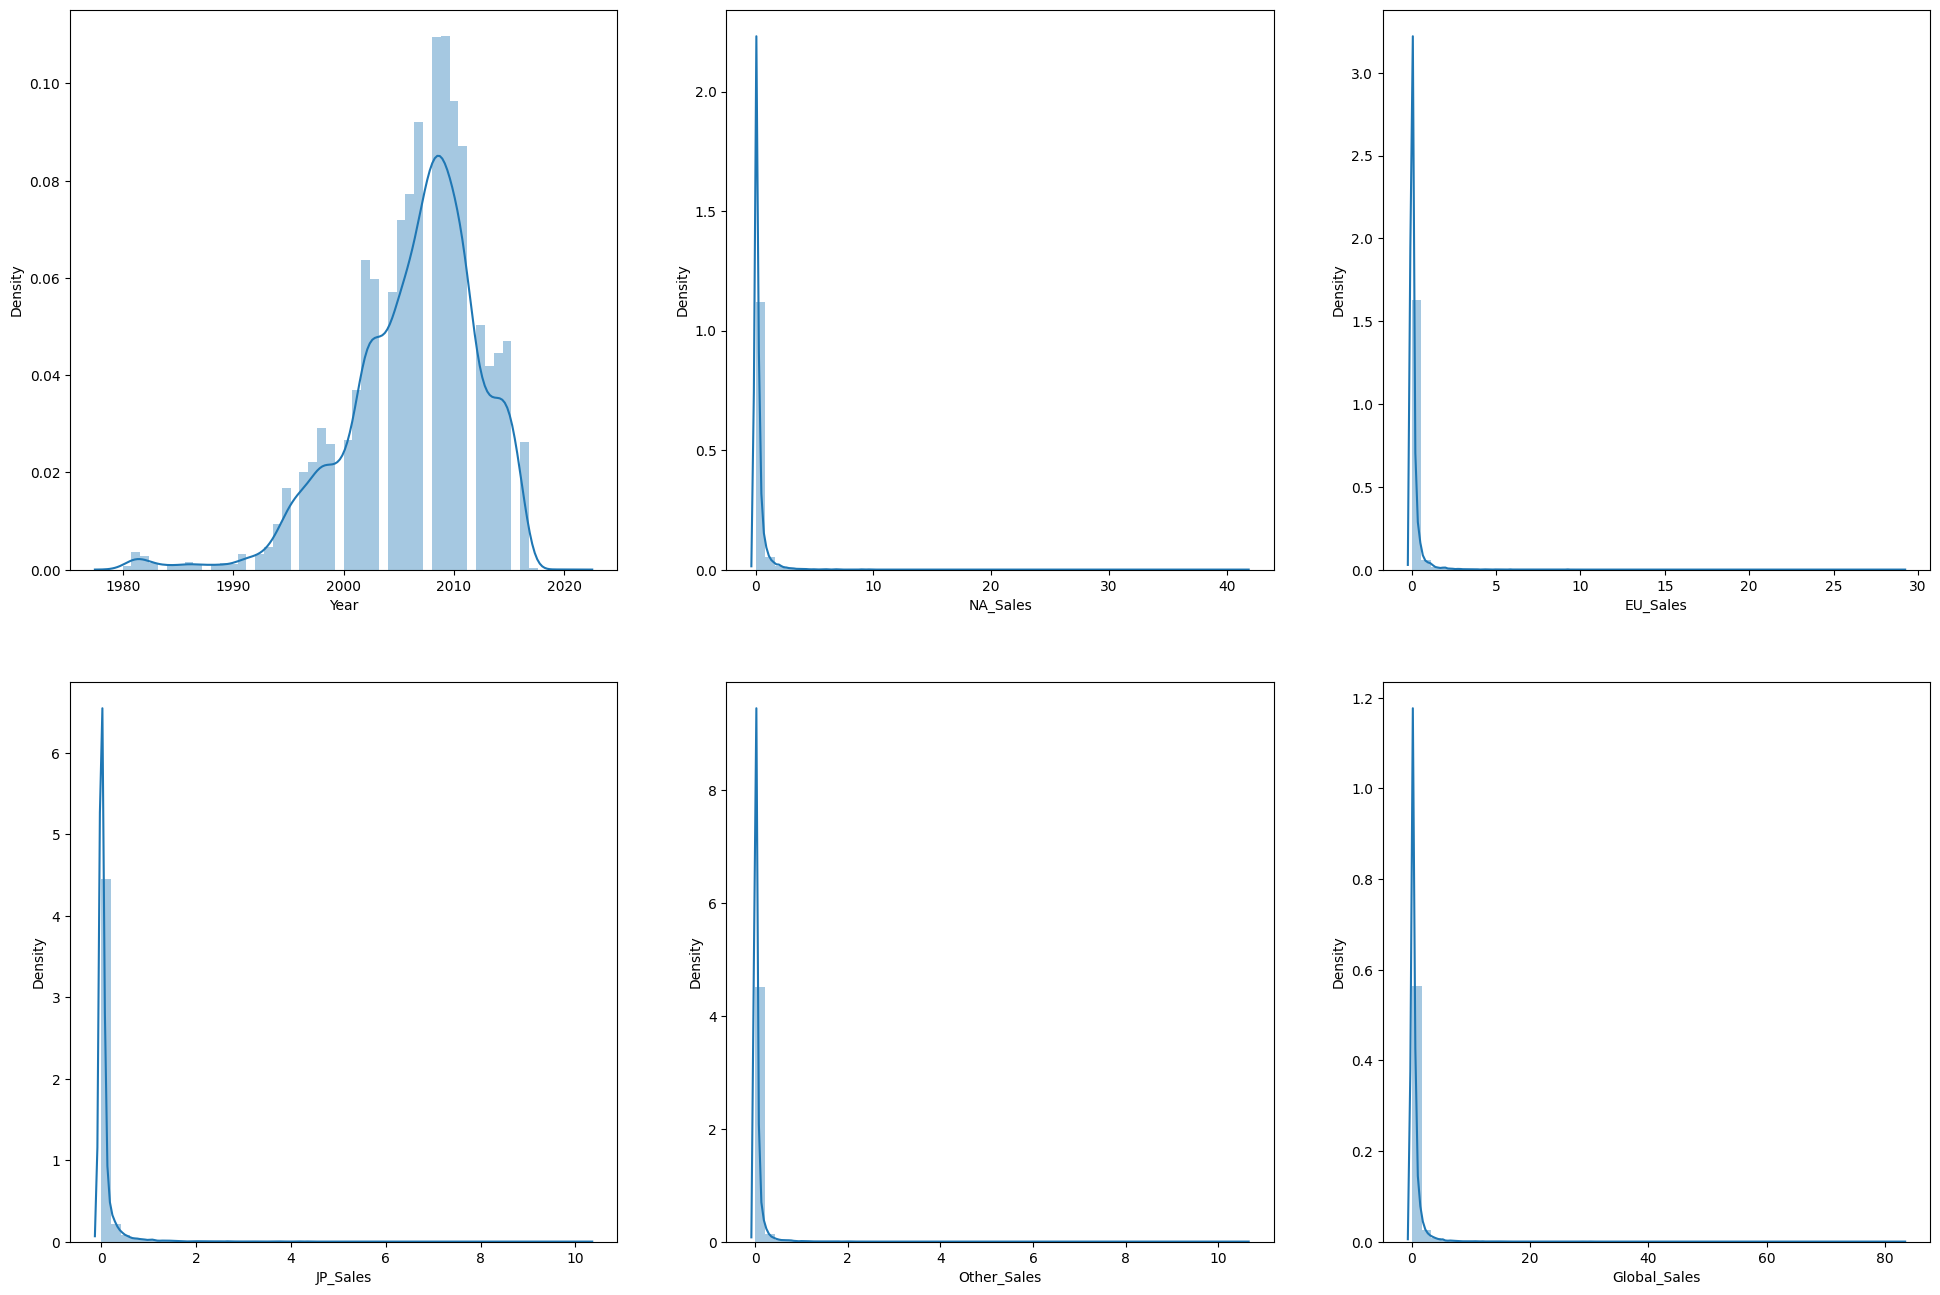

In [315]:
numerical_cols = game_df_clean.select_dtypes(include=['int64','float64']).columns.to_list()
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.distplot(x=game_df_clean[col], ax=ax,)



We can see that the numerical columns are mostly positive skewed

In [316]:
for col in numerical_cols:
  print(f'skewness of {col}: {game_df_clean[col].skew()}')

skewness of Year: -1.0031414622994355
skewness of NA_Sales: 18.71288904862023
skewness of EU_Sales: 18.753076249302147
skewness of JP_Sales: 11.128776899912525
skewness of Other_Sales: 24.073941292432252
skewness of Global_Sales: 17.292000083733008


Then we can apply the transformation to the numerical columns to obtain the normality

skewness of Year: nan
skewness of NA_Sales: 0.5983670041564926
skewness of EU_Sales: 0.8836065149127631
skewness of JP_Sales: 1.2726585622113082
skewness of Other_Sales: 0.9657982824613511
skewness of Global_Sales: 0.5142489720336649


/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1260: RuntimeWarning:

overflow encountered in multiply

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

invalid value encountered in reduce

/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1272: RuntimeWarning:

overflow encountered in scalar power

<ipython-input-317-567e3063d075>:18: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-317-567e3063d075>:18: UserWarning:



`distplot` is a deprecated function and will

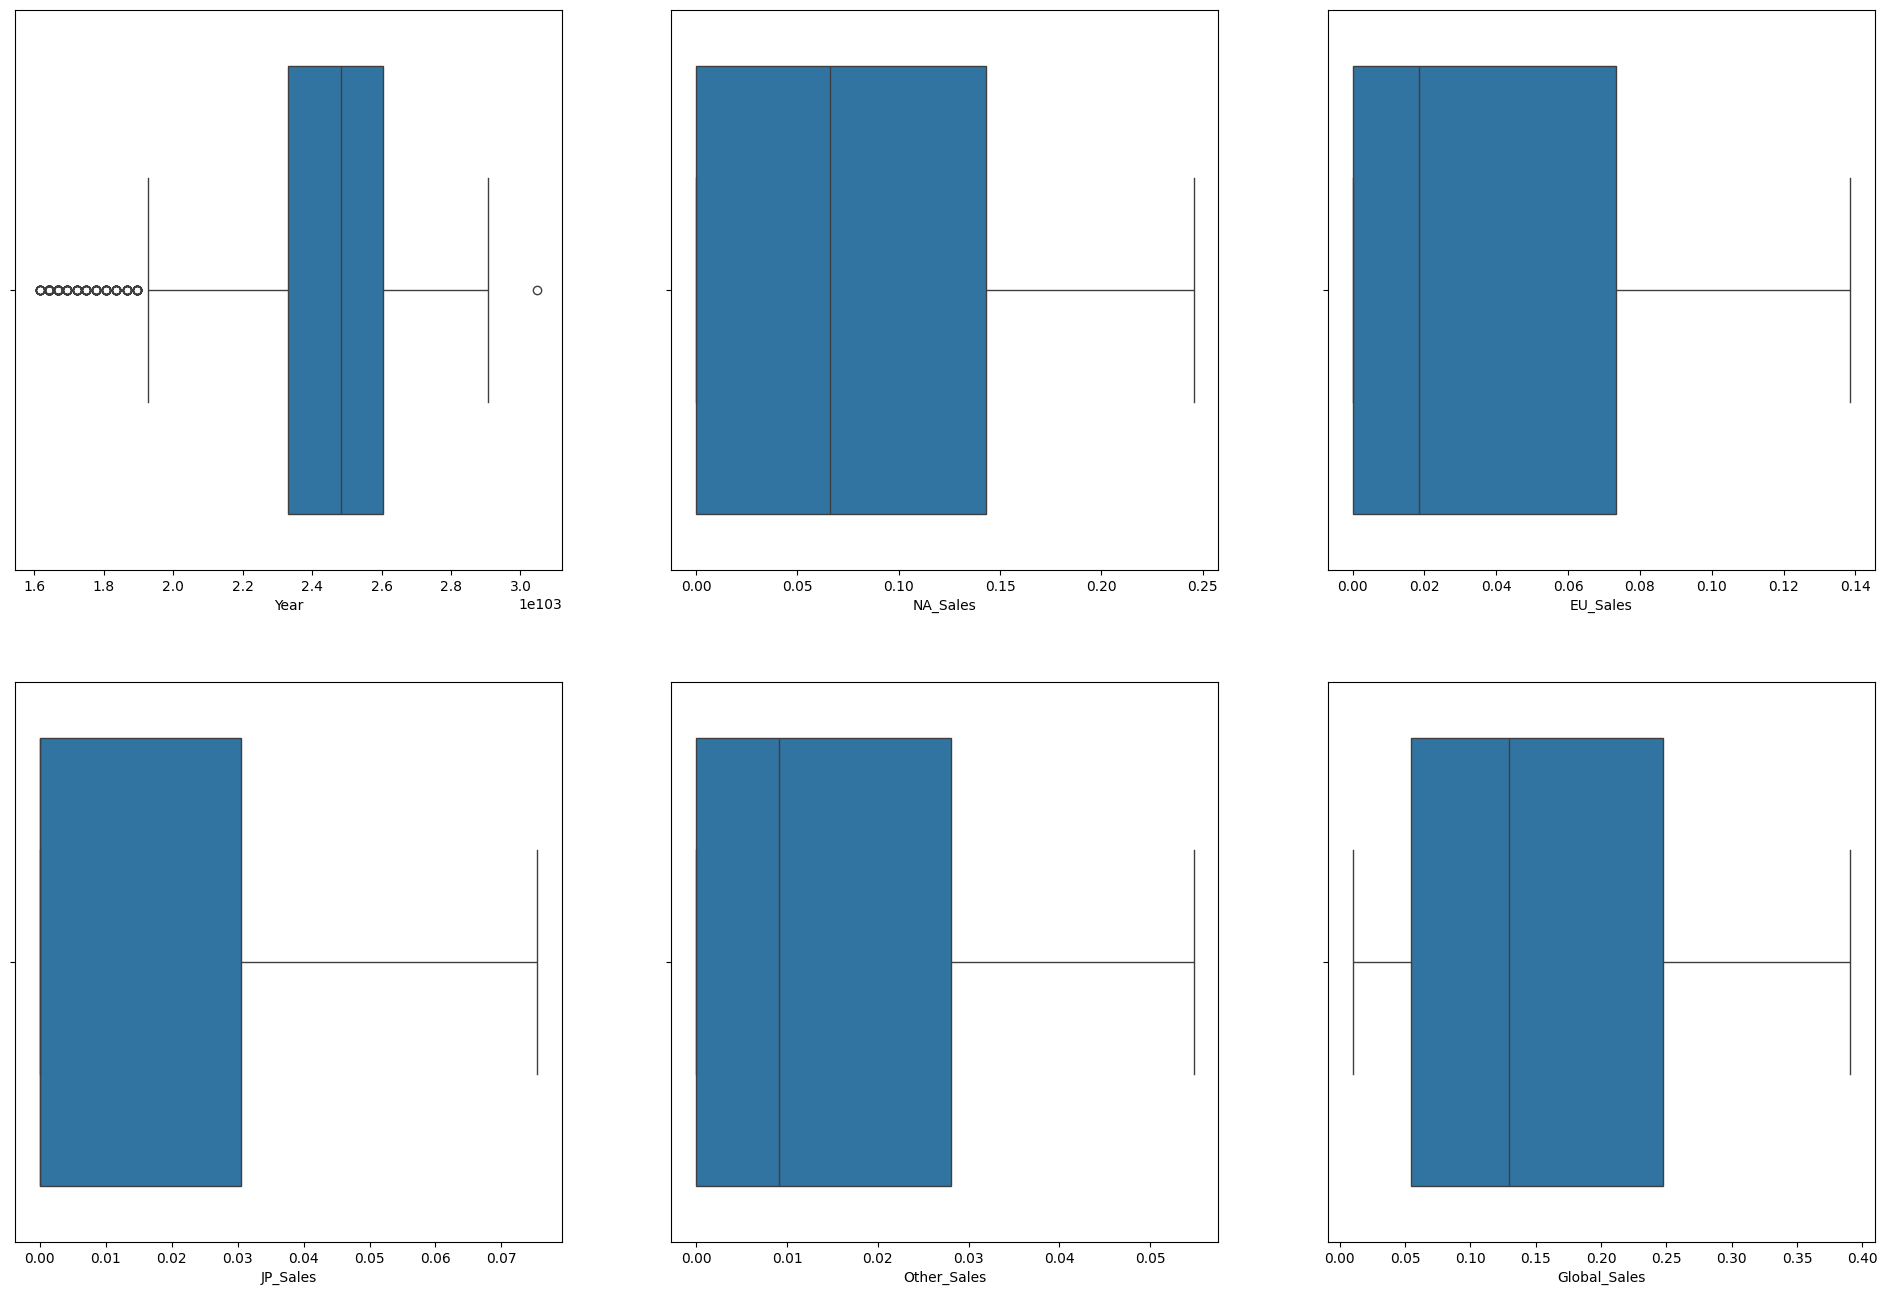

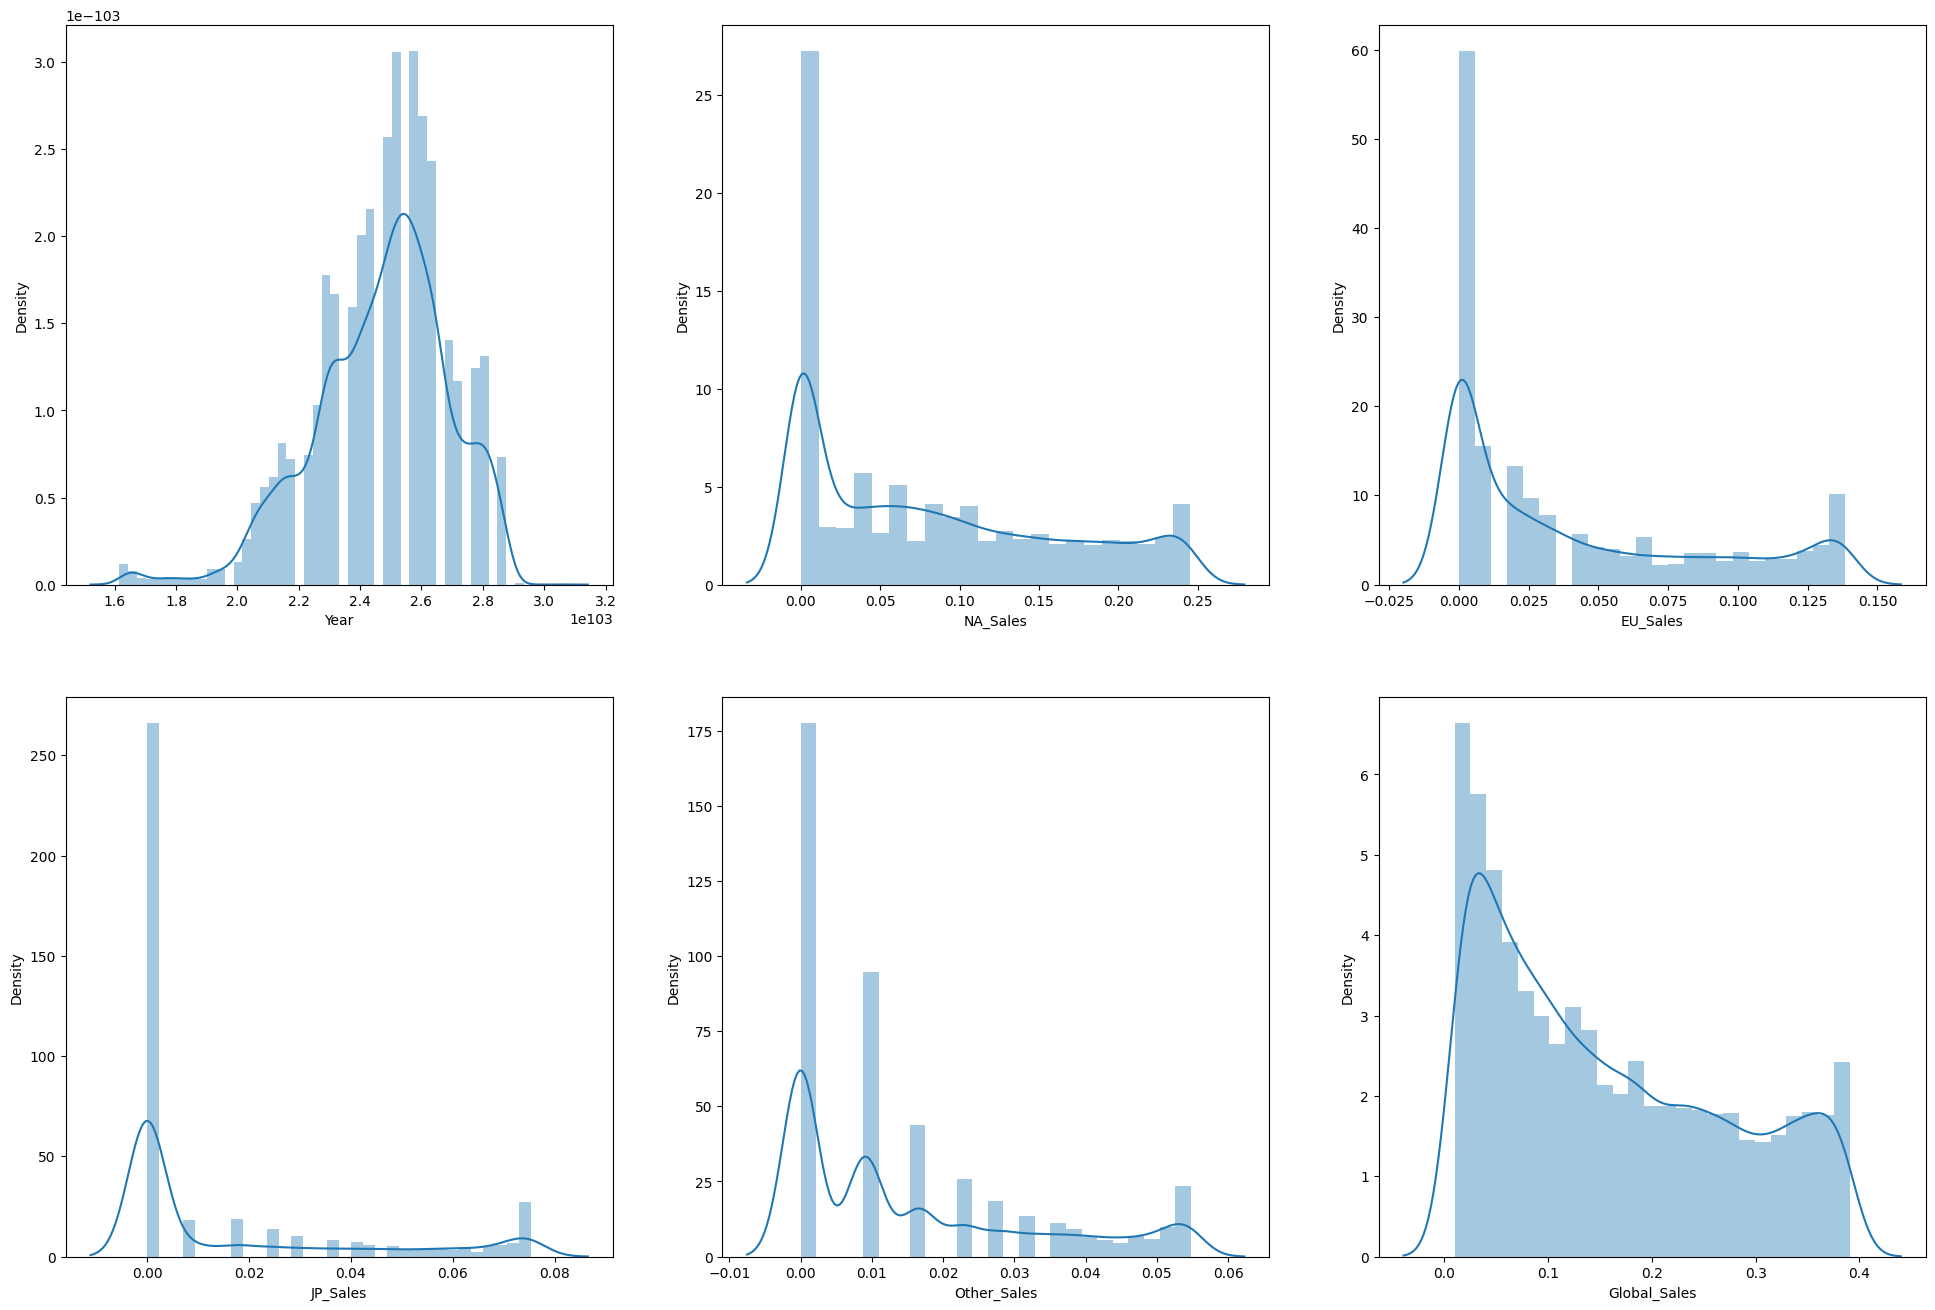

In [317]:
from scipy import stats
lambdas={}
df_game_cox = game_df_clean[numerical_cols].copy()
for col in numerical_cols:
  df_game_cox[col], l = stats.yeojohnson(df_game_cox[col])
  lambdas[col] = l
  print(f'skewness of {col}: {df_game_cox[col].skew()}')

# box plot the numerical columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.boxplot(x=df_game_cox[col], ax=ax,)
# dist plot the numerical columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.distplot(x=df_game_cox[col], ax=ax,)

We can see that the outliers have been processed after the transformation.
Most of the skewness are between -1 and 1, but still some outside this range.
We can try to winsorize some extreme values through the quantile method so that make them less skewed.

skewness of EU_Sales: 0.8694604886789412
skewness of JP_Sales: 1.265302301594
skewness of Other_Sales: 0.9440799259751512


<ipython-input-318-3e9a4ddd0f93>:17: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-318-3e9a4ddd0f93>:17: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-318-3e9a4ddd0f93>:17: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

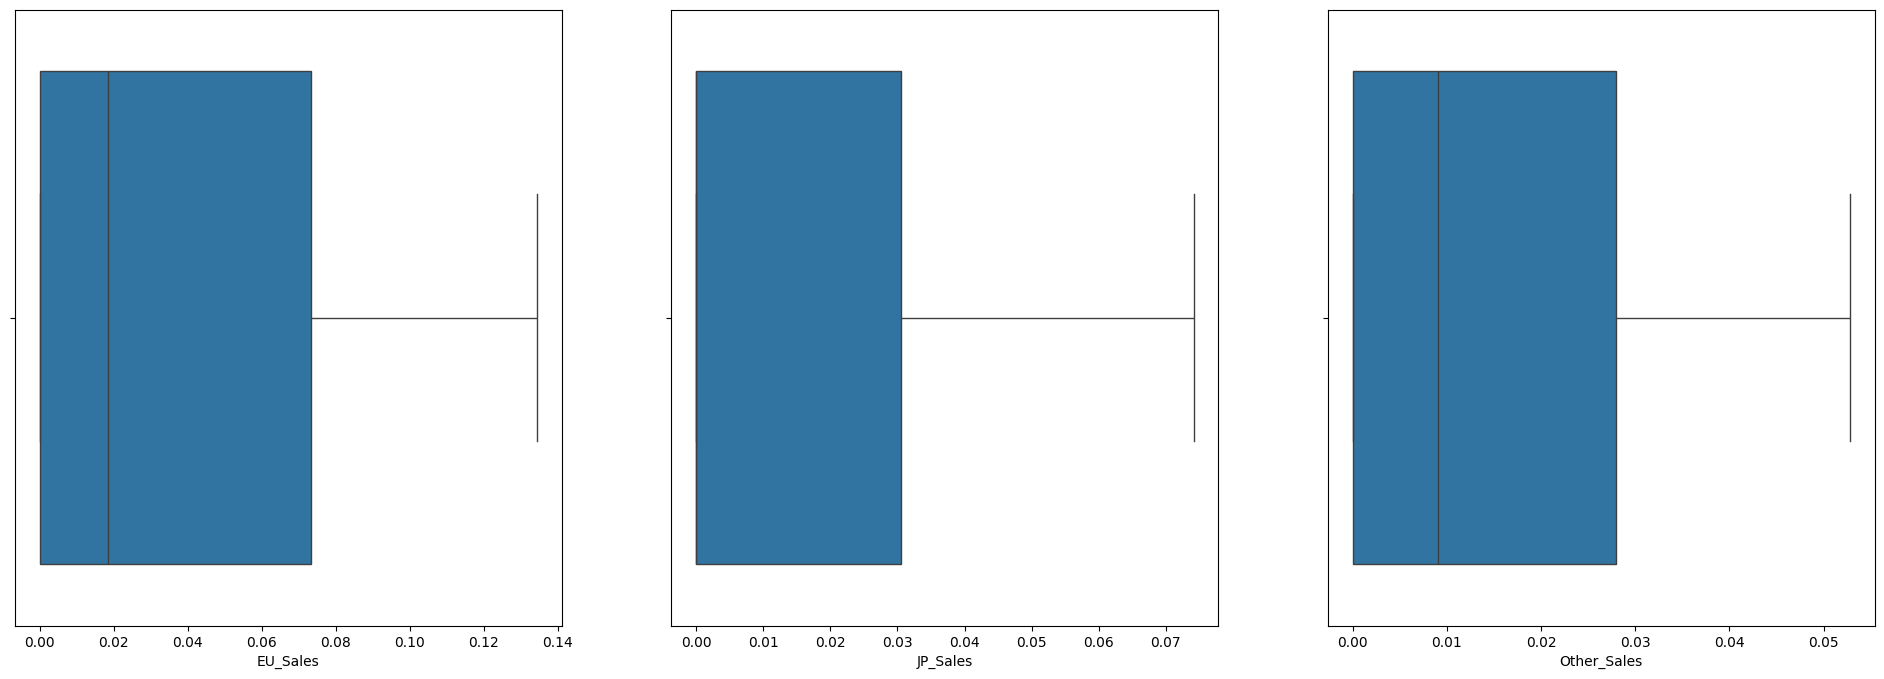

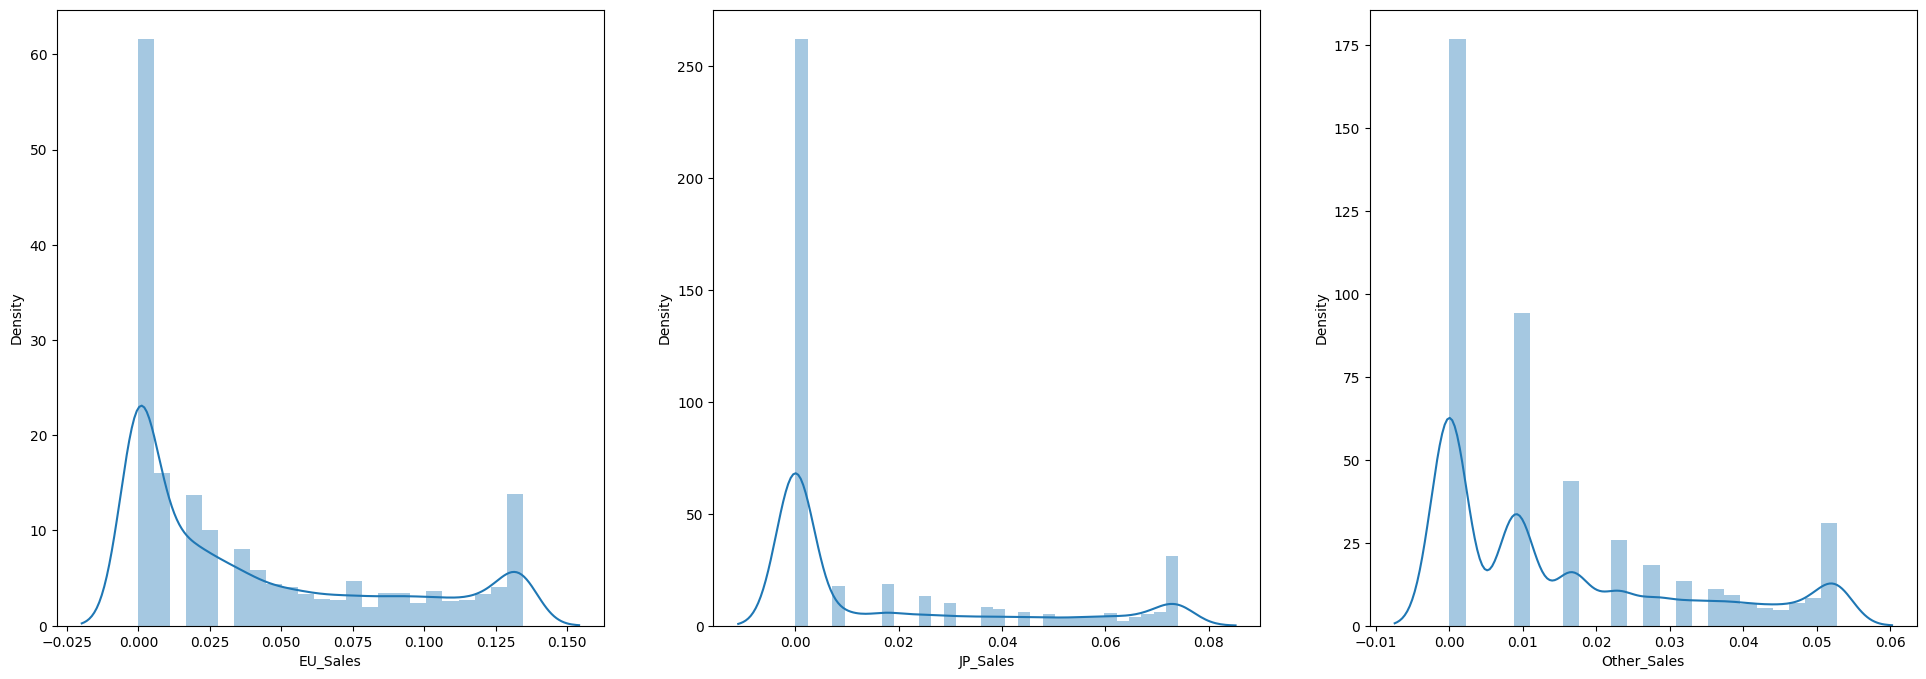

In [318]:
df_game_winsorized = df_game_cox.copy()
winsorized_cols = ['EU_Sales', 'JP_Sales', 'Other_Sales']
for col in winsorized_cols:
  upper_limit = df_game_winsorized[col].quantile(0.95)
  df_game_winsorized.loc[df_game_winsorized[col]>upper_limit, col] = upper_limit
  print(f'skewness of {col}: {df_game_winsorized[col].skew()}')

# box plot the numerical columns
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for col, ax in zip(winsorized_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.boxplot(x=df_game_winsorized[col], ax=ax,)
# dist plot the numerical columns
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for col, ax in zip(winsorized_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.distplot(x=df_game_winsorized[col], ax=ax,)

We can see the results are not sigificant, so it is decided not to use the winsorization. Here we can encode the numerical Sales into categorical variables (add new features).

In [319]:
df_game_distcretize = df_game_cox.copy()
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
transformer = ColumnTransformer(transformers=[('Numerical Discretizer', discretizer, ['EU_Sales', 'JP_Sales', 'Other_Sales'])], remainder='drop')

In [320]:
d = pd.DataFrame(data=transformer.fit_transform(df_game_distcretize), columns=['EU_Sales_Label', 'JP_Sales_Label', 'Other_Sales_Label'])
df_game_distcretize = pd.concat([df_game_distcretize, d], axis=1)
df_game_distcretize.head()

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.



,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,EU_Sales_Label,JP_Sales_Label,Other_Sales_Label
0,2.444211e+103,0.245492,0.138475,0.075397,0.054770,0.390545,3.0,1.0,3.0
1,1.750062e+103,0.245492,0.138473,0.075397,0.054768,0.390521,3.0,1.0,3.0
2,2.522766e+103,0.245490,0.138475,0.075397,0.054770,0.390512,3.0,1.0,3.0
3,2.562956e+103,0.245489,0.138475,0.075397,0.054770,0.390503,3.0,1.0,3.0
4,2.085647e+103,0.245483,0.138475,0.075397,0.054770,0.390497,3.0,1.0,3.0


,count
EU_Sales_Label,
0.0,5627
2.0,3765
1.0,3631
3.0,3282


,count
JP_Sales_Label,
0.0,12867
1.0,3438


,count
Other_Sales_Label,
0.0,6340
3.0,3446
1.0,3381
2.0,3138


skewness of EU_Sales_Label: 0.23613613426484462
skewness of JP_Sales_Label: 1.4177968445000706
skewness of Other_Sales_Label: 0.34033009897538424


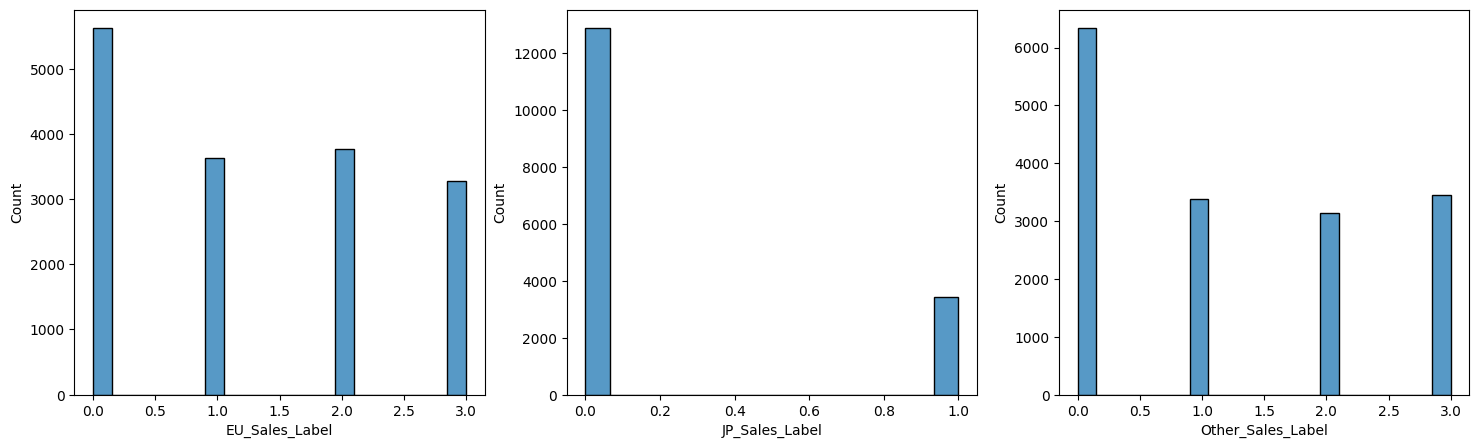

In [321]:
labels = ['EU_Sales_Label',	'JP_Sales_Label',	'Other_Sales_Label']
for label in labels:
  display(df_game_distcretize[label].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, ax in zip(labels, axes.flatten()):
  ax.set_xlabel(col)
  sns.histplot(df_game_distcretize[col], ax=ax,)

for col in labels:
  print(f'skewness of {col}: {df_game_distcretize[col].skew()}')

Now, we use the Robust Scalet to scale down the numerical data (which remain the original distribution, as well as the skewness).

In [322]:
from sklearn.preprocessing import RobustScaler
df_game_cox = pd.DataFrame(data=RobustScaler().fit_transform(df_game_cox), columns=df_game_cox.columns.to_list())
display(df_game_cox.head())
display(df_game_cox.describe())

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,-0.142792,1.252253,1.637393,2.465521,1.630740,1.351654
1,-2.685809,1.252252,1.637361,2.465521,1.630682,1.351530
2,0.144997,1.252236,1.637393,2.465521,1.630740,1.351480
3,0.292230,1.252236,1.637393,2.465521,1.630740,1.351436
4,-1.456393,1.252190,1.637393,2.465521,1.630734,1.351403


,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000
mean,-0.049135,0.116407,0.304704,0.541695,0.221980,0.141810
std,0.801065,0.549942,0.630174,0.841916,0.621841,0.592586
min,-3.179101,-0.461082,-0.251725,0.000000,-0.324884,-0.618011
25%,-0.558266,-0.461082,-0.251725,0.000000,-0.324884,-0.388794
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.441734,0.538918,0.748275,1.000000,0.675116,0.611206
max,2.069352,1.252253,1.637393,2.465521,1.630740,1.351654


<ipython-input-323-342291cfc8f3>:10: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-323-342291cfc8f3>:10: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-323-342291cfc8f3>:10: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

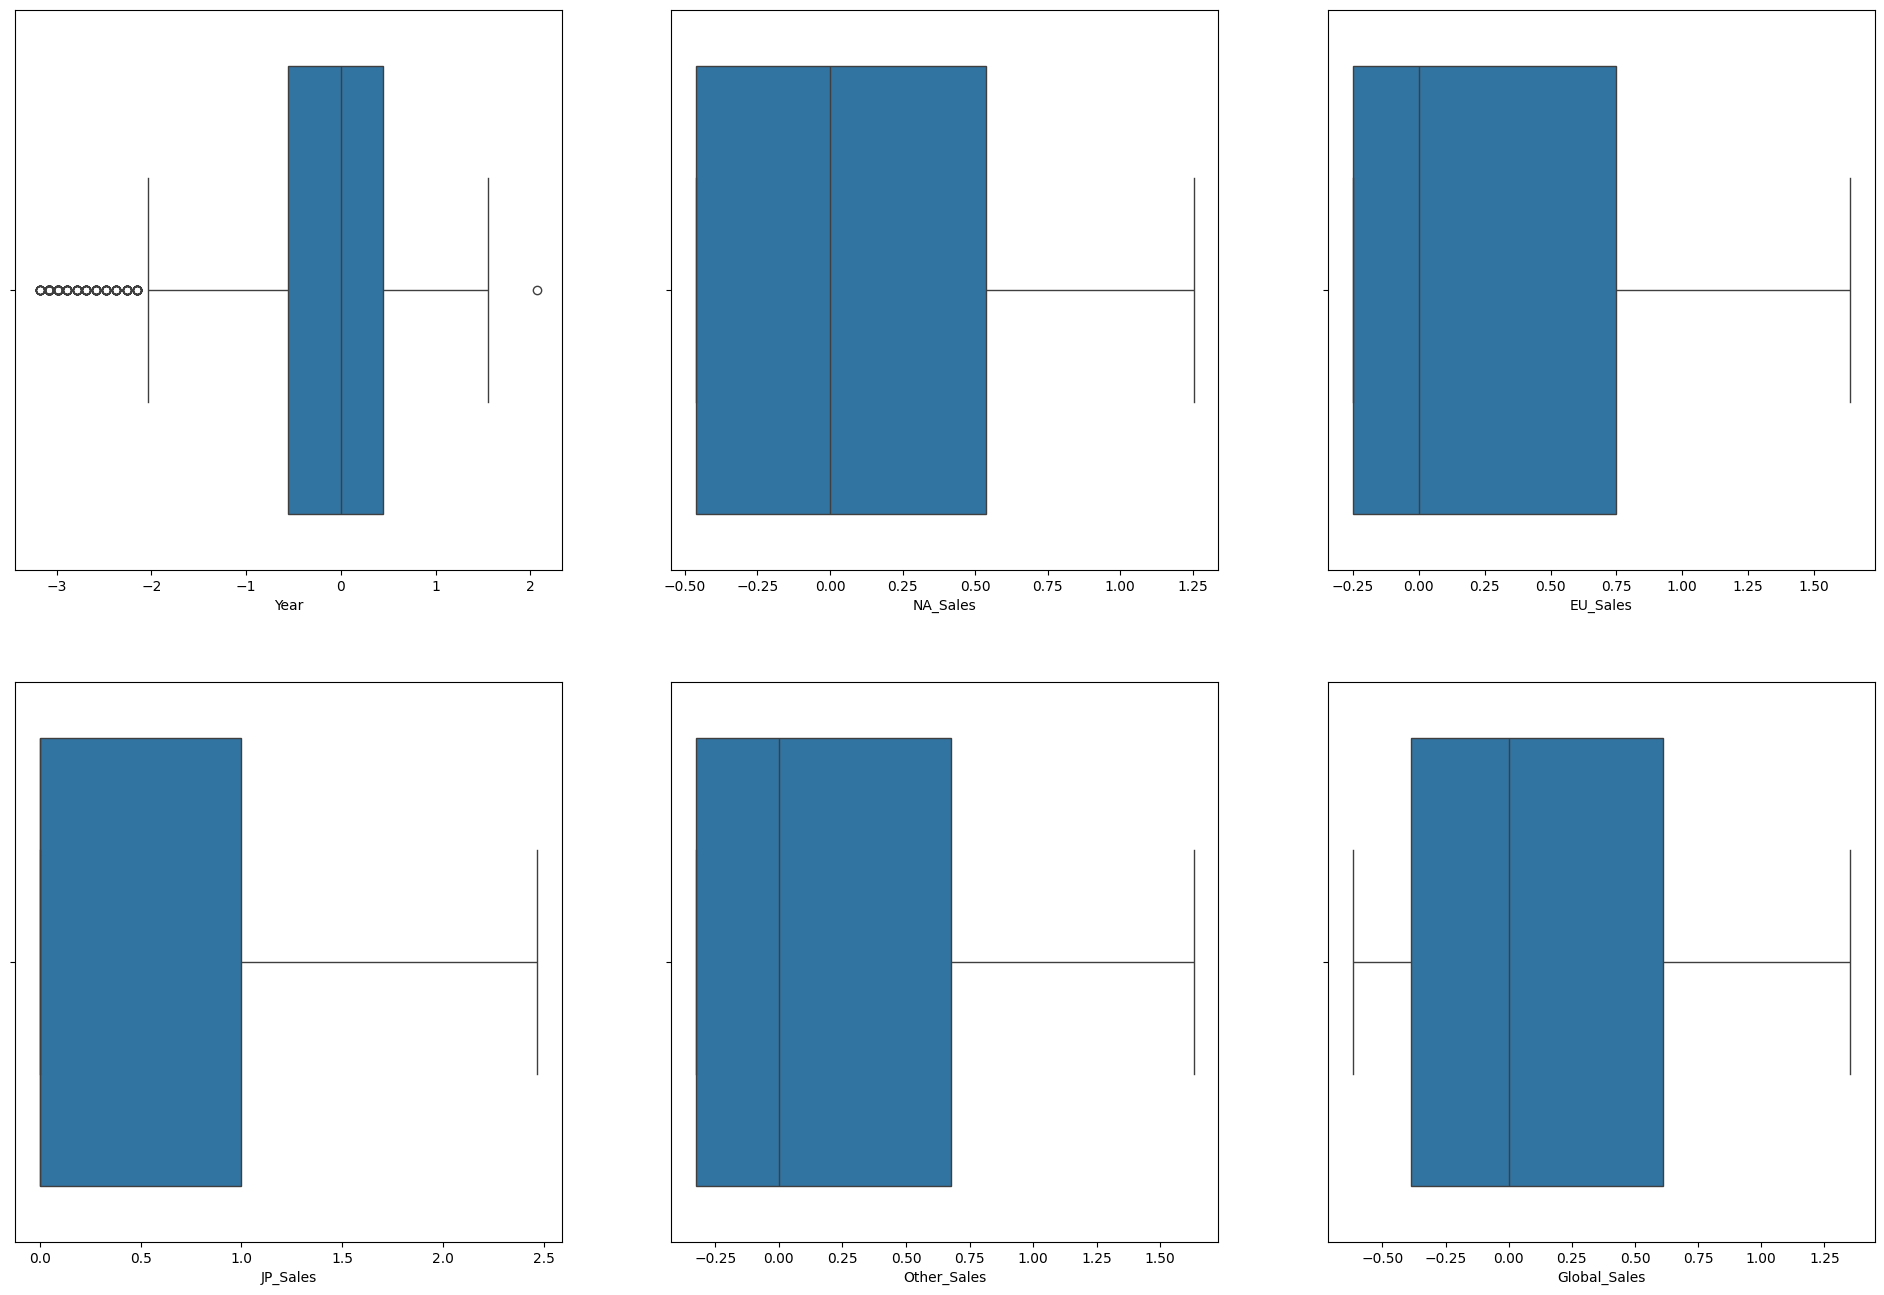

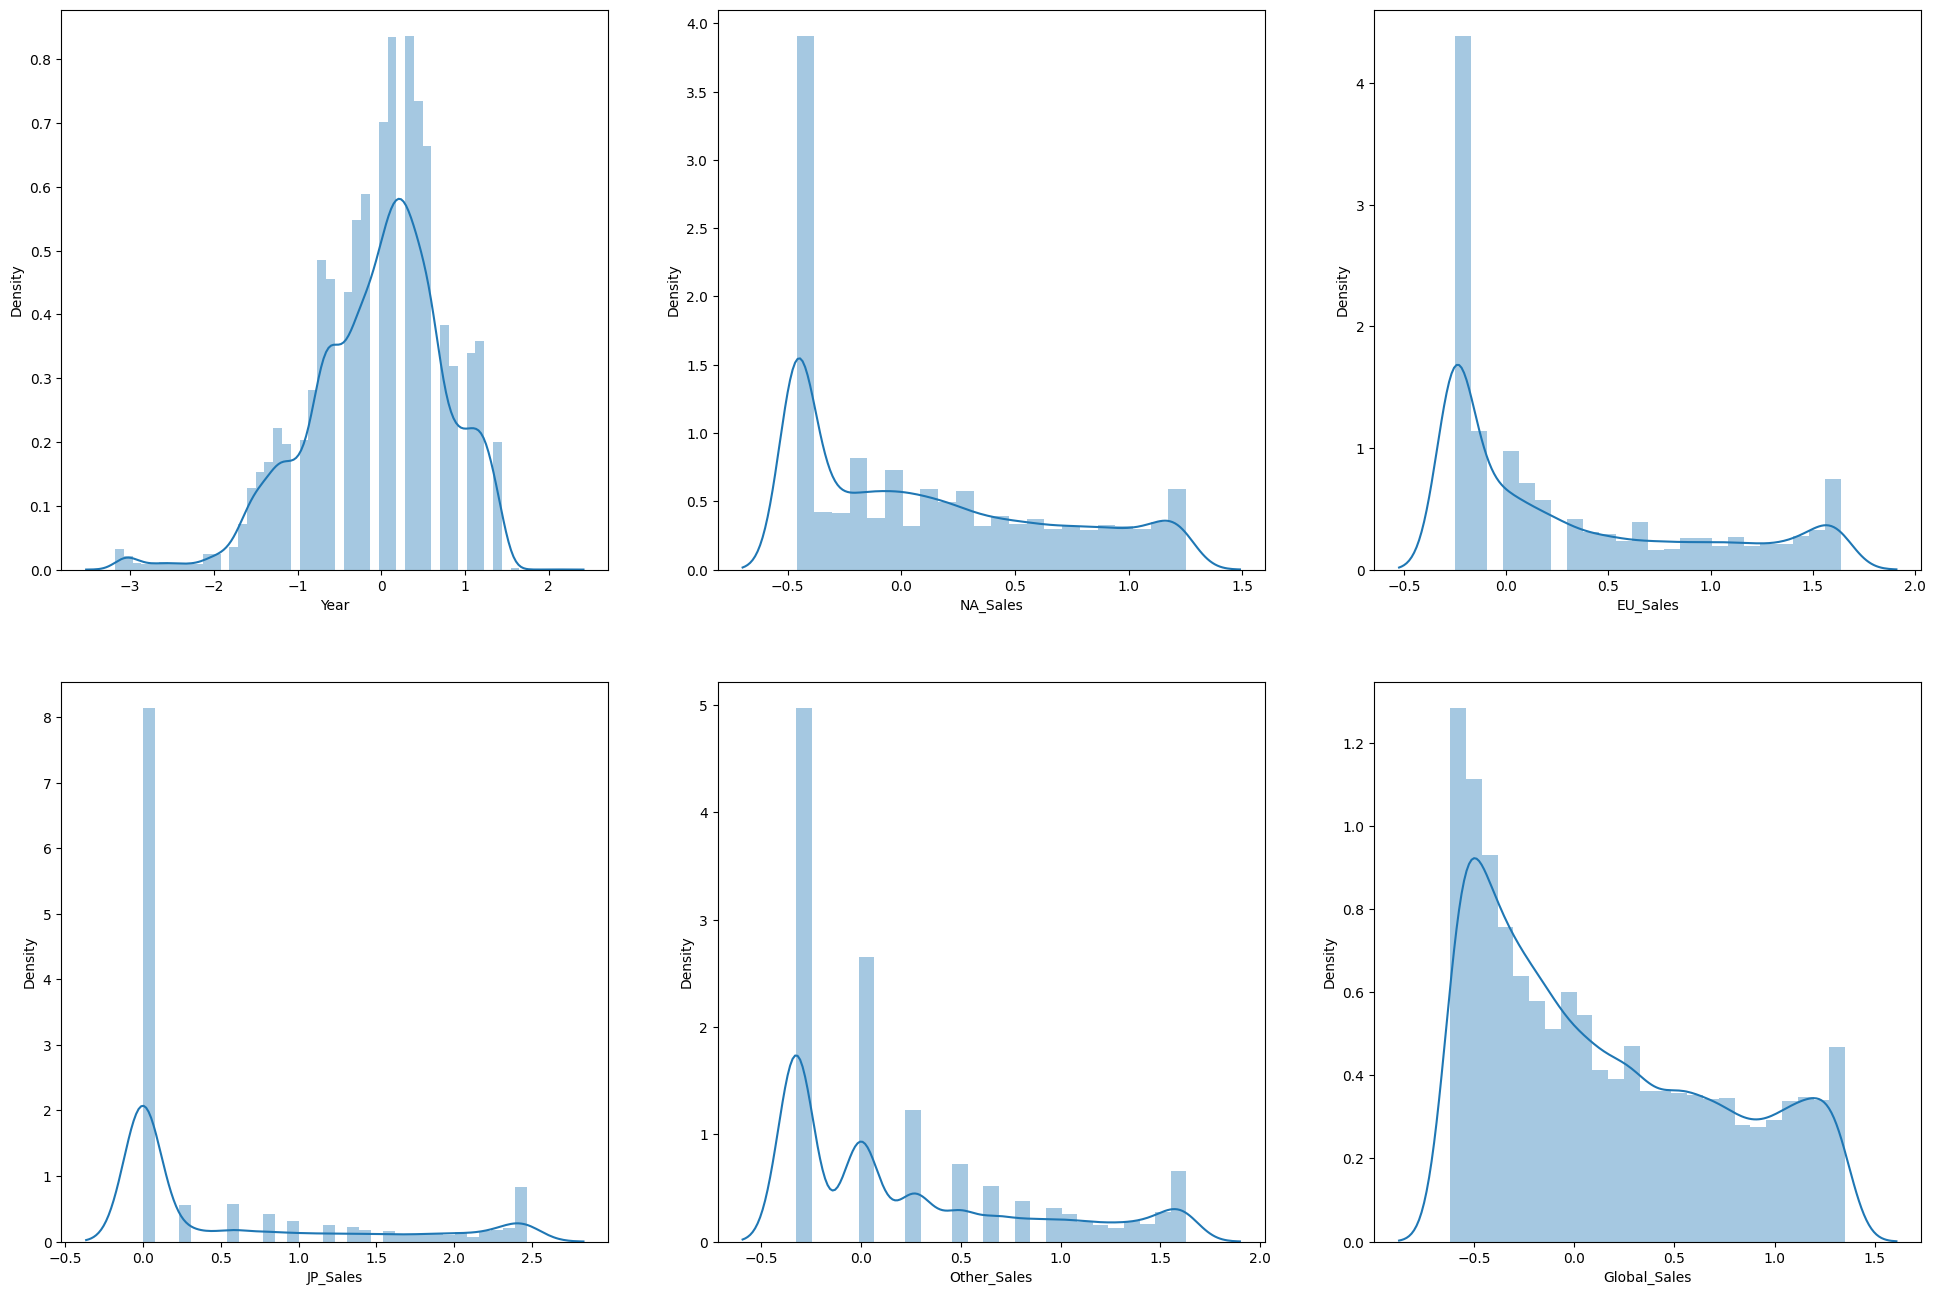

In [323]:
# box plot the numerical columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.boxplot(x=df_game_cox[col], ax=ax,)
# dist plot the numerical columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for col, ax in zip(numerical_cols, axes.flatten()):
  ax.set_xlabel(col)
  sns.distplot(x=df_game_cox[col], ax=ax,)

In [324]:
for col in numerical_cols:
  print(f'skewness of {col}: {df_game_cox[col].skew()}')

skewness of Year: -0.6565951192975605
skewness of NA_Sales: 0.5983670041564927
skewness of EU_Sales: 0.883606514912763
skewness of JP_Sales: 1.2726585622113087
skewness of Other_Sales: 0.9657982824613514
skewness of Global_Sales: 0.5142489720336652


In [325]:
df_game_cox

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,-0.142792,1.252253,1.637393,2.465521,1.630740,1.351654
1,-2.685809,1.252252,1.637361,2.465521,1.630682,1.351530
2,0.144997,1.252236,1.637393,2.465521,1.630740,1.351480
3,0.292230,1.252236,1.637393,2.465521,1.630740,1.351436
4,-1.456393,1.252190,1.637393,2.465521,1.630734,1.351403
...,...,...,...,...,...,...
16300,-0.692561,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16301,-0.558266,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16302,0.144997,-0.461082,-0.251725,0.000000,-0.324884,-0.618011
16303,0.441734,-0.461082,-0.120742,0.000000,-0.324884,-0.618011


Now, we process the categorical columns.

In [326]:
object_columns = game_df_clean.select_dtypes(include=['object']).columns.to_list()
game_df_obj = game_df_clean.copy()
game_df_obj = game_df_obj.reset_index()
game_df_obj[numerical_cols] = df_game_cox[numerical_cols]
game_df_obj

,index,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,0,Wii Sports,Wii,-0.142792,Sports,Nintendo,1.252253,1.637393,2.465521,1.630740,1.351654
1,1,Super Mario Bros.,NES,-2.685809,Platform,Nintendo,1.252252,1.637361,2.465521,1.630682,1.351530
2,2,Mario Kart Wii,Wii,0.144997,Racing,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351480
3,3,Wii Sports Resort,Wii,0.292230,Sports,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351436
4,4,Pokemon Red/Pokemon Blue,GB,-1.456393,Role-Playing,Nintendo,1.252190,1.637393,2.465521,1.630734,1.351403
...,...,...,...,...,...,...,...,...,...,...,...
16300,16593,Woody Woodpecker in Crazy Castle 5,GBA,-0.692561,Platform,Kemco,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16301,16594,Men in Black II: Alien Escape,GC,-0.558266,Shooter,Infogrames,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16302,16595,SCORE International Baja 1000: The Official Game,PS2,0.144997,Racing,Activision,-0.461082,-0.251725,0.000000,-0.324884,-0.618011
16303,16596,Know How 2,DS,0.441734,Puzzle,7G//AMES,-0.461082,-0.120742,0.000000,-0.324884,-0.618011


Here we can drop the column 'Name'.

In [327]:
object_columns.remove('Name')
game_df_obj.drop(columns='Name', inplace=True)
game_df_obj.head()

,index,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,0,Wii,-0.142792,Sports,Nintendo,1.252253,1.637393,2.465521,1.630740,1.351654
1,1,NES,-2.685809,Platform,Nintendo,1.252252,1.637361,2.465521,1.630682,1.351530
2,2,Wii,0.144997,Racing,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351480
3,3,Wii,0.292230,Sports,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351436
4,4,GB,-1.456393,Role-Playing,Nintendo,1.252190,1.637393,2.465521,1.630734,1.351403


Handling the Publisher Column: We first select the top 25 Publisher (that has top 25 Global Sales) and replace other with 'Other'

In [328]:
top = 25
counts = (game_df_obj.groupby('Publisher')['Global_Sales'].sum()).sort_values(ascending=False).reset_index().iloc[top:, :]
display(counts)
not_need_val = counts['Publisher'].values.tolist()
game_df_obj.loc[game_df_obj['Publisher'].isin(not_need_val), 'Publisher_Label'] = 'Other'
display(game_df_obj['Publisher'].value_counts())

,Publisher,Global_Sales
25,Sony Computer Entertainment Europe,12.078528
26,Universal Interactive,11.833194
27,MTV Games,11.745587
28,989 Studios,10.834808
29,Codemasters,10.681977
...,...,...
571,Unknown,-26.356305
572,5pb,-32.926237
573,D3Publisher,-44.321081
574,Tecmo Koei,-55.312598


,count
Publisher,
Electronic Arts,1343
Activision,966
Namco Bandai Games,928
Ubisoft,918
Konami Digital Entertainment,823
...,...
King Records,1
Graphsim Entertainment,1
Takuyo,1


In [329]:
game_df_obj['Publisher'].value_counts(normalize=True)

,proportion
Publisher,
Electronic Arts,0.082367
Activision,0.059246
Namco Bandai Games,0.056915
Ubisoft,0.056302
Konami Digital Entertainment,0.050475
...,...
King Records,0.000061
Graphsim Entertainment,0.000061
Takuyo,0.000061


We can see that the 'Other' category maintain almost 40% of the total, it may cause class imbalance. Therefore, we further split the 'Other' category into 'Other_Small', 'Other_Mid' and 'Other_High'.

In [330]:
game_df_obj = game_df_clean.copy().reset_index()
game_df_obj[numerical_cols] = df_game_cox[numerical_cols]
game_df_obj.drop(columns='Name', inplace=True)
game_df_obj.head()

top = 25
counts = (game_df_obj.groupby('Publisher')['Global_Sales'].sum()).sort_values(ascending=False).reset_index()
display(counts)
cgs = (counts.iloc[top:, :])['Global_Sales']
cuts = [cgs.min()-0.1, cgs.quantile(0.33), cgs.quantile(0.66), cgs.max()+0.1]
counts['Publisher Label'] = pd.concat([(counts.iloc[:25,:])['Publisher'], pd.cut(cgs, bins=cuts, labels=['Other_Small', 'Other_Mid', 'Other_High'])],
                                      axis=0)
display(counts)
counts = counts.set_index('Publisher')

,Publisher,Global_Sales
0,Electronic Arts,699.161638
1,Nintendo,525.423500
2,Activision,326.956839
3,Sony Computer Entertainment,288.879381
4,THQ,219.058323
...,...,...
571,Unknown,-26.356305
572,5pb,-32.926237
573,D3Publisher,-44.321081
574,Tecmo Koei,-55.312598


,Publisher,Global_Sales,Publisher Label
0,Electronic Arts,699.161638,Electronic Arts
1,Nintendo,525.423500,Nintendo
2,Activision,326.956839,Activision
3,Sony Computer Entertainment,288.879381,Sony Computer Entertainment
4,THQ,219.058323,THQ
...,...,...,...
571,Unknown,-26.356305,Other_Small
572,5pb,-32.926237,Other_Small
573,D3Publisher,-44.321081,Other_Small
574,Tecmo Koei,-55.312598,Other_Small


In [331]:
publisher_dict = counts['Publisher Label'].to_dict()
game_df_obj['Publisher'] = game_df_obj['Publisher'].map(publisher_dict, na_action='ignore' )
game_df_obj

,index,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,0,Wii,-0.142792,Sports,Nintendo,1.252253,1.637393,2.465521,1.630740,1.351654
1,1,NES,-2.685809,Platform,Nintendo,1.252252,1.637361,2.465521,1.630682,1.351530
2,2,Wii,0.144997,Racing,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351480
3,3,Wii,0.292230,Sports,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351436
4,4,GB,-1.456393,Role-Playing,Nintendo,1.252190,1.637393,2.465521,1.630734,1.351403
...,...,...,...,...,...,...,...,...,...,...
16300,16593,GBA,-0.692561,Platform,Other_Small,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16301,16594,GC,-0.558266,Shooter,Other_High,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16302,16595,PS2,0.144997,Racing,Activision,-0.461082,-0.251725,0.000000,-0.324884,-0.618011
16303,16596,DS,0.441734,Puzzle,Other_Small,-0.461082,-0.120742,0.000000,-0.324884,-0.618011


In [332]:
game_df_obj['Publisher'].value_counts(normalize=True)

,proportion
Publisher,
Other_Small,0.298068
Electronic Arts,0.082367
Other_High,0.067035
Activision,0.059246
Ubisoft,0.056302
Konami Digital Entertainment,0.050475
THQ,0.043668
Nintendo,0.042686
Sony Computer Entertainment,0.041828


Handling the Platform Column: Replcae the categories that sum of them is less than 5% of the total with 'Other' Category

In [333]:
threshold = 0.05
counts = (game_df_obj['Platform'].value_counts()/len(game_df_obj)).sort_values(ascending=True).reset_index()
counts['cum_sum'] = counts['count'].cumsum()
not_need_val = counts[counts['cum_sum']<threshold]['Platform'].values.tolist()
game_df_obj.loc[game_df_obj['Platform'].isin(not_need_val), 'Platform'] = 'Other'
display(game_df_obj['Platform'].value_counts())

display(game_df_obj[game_df_obj['Platform']=='Other']['Platform'].value_counts()/len(game_df_obj))

,count
Platform,
PS2,2133
DS,2132
PS3,1304
Wii,1290
X360,1236
PSP,1198
PS,1189
PC,938
XB,806


,count
Platform,
Other,0.045201


We do not process the Genre Column as there are only 12 categories in total, and the lowest category, `Puzzle`, has 3.5%, which is not extremely sparse.

In [334]:
game_df_obj['Genre'].value_counts(normalize=True)

,proportion
Genre,
Action,0.199387
Sports,0.141981
Misc,0.103404
Role-Playing,0.090156
Shooter,0.078626
Adventure,0.078136
Racing,0.075314
Platform,0.053665
Simulation,0.052009


In [335]:
game_df_obj.drop(columns='index', inplace=True)
game_df_obj

,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii,-0.142792,Sports,Nintendo,1.252253,1.637393,2.465521,1.630740,1.351654
1,Other,-2.685809,Platform,Nintendo,1.252252,1.637361,2.465521,1.630682,1.351530
2,Wii,0.144997,Racing,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351480
3,Wii,0.292230,Sports,Nintendo,1.252236,1.637393,2.465521,1.630740,1.351436
4,Other,-1.456393,Role-Playing,Nintendo,1.252190,1.637393,2.465521,1.630734,1.351403
...,...,...,...,...,...,...,...,...,...
16300,GBA,-0.692561,Platform,Other_Small,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16301,GC,-0.558266,Shooter,Other_High,-0.393025,-0.251725,0.000000,-0.324884,-0.618011
16302,PS2,0.144997,Racing,Activision,-0.461082,-0.251725,0.000000,-0.324884,-0.618011
16303,DS,0.441734,Puzzle,Other_Small,-0.461082,-0.120742,0.000000,-0.324884,-0.618011


We one-hot encoding the categorical columns

In [346]:
game_df_final = pd.get_dummies(game_df_obj, columns=object_columns, drop_first='True')
game_df_final[['EU_Sales_Label',	'JP_Sales_Label',	'Other_Sales_Label']] = df_game_distcretize[['EU_Sales_Label',	'JP_Sales_Label',	'Other_Sales_Label']]
game_df_final

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform_DS,Platform_GBA,Platform_GC,Platform_N64,...,Publisher_SquareSoft,Publisher_THQ,Publisher_Take-Two Interactive,Publisher_Ubisoft,Publisher_Virgin Interactive,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,EU_Sales_Label,JP_Sales_Label,Other_Sales_Label
0,-0.142792,1.252253,1.637393,2.465521,1.630740,1.351654,False,False,False,False,...,False,False,False,False,False,False,False,3.0,1.0,3.0
1,-2.685809,1.252252,1.637361,2.465521,1.630682,1.351530,False,False,False,False,...,False,False,False,False,False,False,False,3.0,1.0,3.0
2,0.144997,1.252236,1.637393,2.465521,1.630740,1.351480,False,False,False,False,...,False,False,False,False,False,False,False,3.0,1.0,3.0
3,0.292230,1.252236,1.637393,2.465521,1.630740,1.351436,False,False,False,False,...,False,False,False,False,False,False,False,3.0,1.0,3.0
4,-1.456393,1.252190,1.637393,2.465521,1.630734,1.351403,False,False,False,False,...,False,False,False,False,False,False,False,3.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16300,-0.692561,-0.393025,-0.251725,0.000000,-0.324884,-0.618011,False,True,False,False,...,False,False,False,False,False,False,False,0.0,0.0,0.0
16301,-0.558266,-0.393025,-0.251725,0.000000,-0.324884,-0.618011,False,False,True,False,...,False,False,False,False,False,False,False,0.0,0.0,0.0
16302,0.144997,-0.461082,-0.251725,0.000000,-0.324884,-0.618011,False,False,False,False,...,False,False,False,False,False,False,False,0.0,0.0,0.0
16303,0.441734,-0.461082,-0.120742,0.000000,-0.324884,-0.618011,True,False,False,False,...,False,False,False,False,False,False,False,1.0,0.0,0.0


In [347]:
display(lambdas)
game_df_final.columns.to_list()

{'Year': np.float64(31.76033890014357),
 'NA_Sales': np.float64(-4.073452660956766),
 'EU_Sales': np.float64(-7.221495458863384),
 'JP_Sales': np.float64(-13.26320659631902),
 'Other_Sales': np.float64(-18.258210507261627),
 'Global_Sales': np.float64(-2.560492237061332)}

['Year',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales',
 'Platform_DS',
 'Platform_GBA',
 'Platform_GC',
 'Platform_N64',
 'Platform_Other',
 'Platform_PC',
 'Platform_PS',
 'Platform_PS2',
 'Platform_PS3',
 'Platform_PS4',
 'Platform_PSP',
 'Platform_PSV',
 'Platform_SNES',
 'Platform_Wii',
 'Platform_X360',
 'Platform_XB',
 'Platform_XOne',
 'Genre_Adventure',
 'Genre_Fighting',
 'Genre_Misc',
 'Genre_Platform',
 'Genre_Puzzle',
 'Genre_Racing',
 'Genre_Role-Playing',
 'Genre_Shooter',
 'Genre_Simulation',
 'Genre_Sports',
 'Genre_Strategy',
 'Publisher_Activision',
 'Publisher_Atari',
 'Publisher_Bethesda Softworks',
 'Publisher_Capcom',
 'Publisher_Disney Interactive Studios',
 'Publisher_Eidos Interactive',
 'Publisher_Electronic Arts',
 'Publisher_Enix Corporation',
 'Publisher_GT Interactive',
 'Publisher_Konami Digital Entertainment',
 'Publisher_LucasArts',
 'Publisher_Microsoft Game Studios',
 'Publisher_Midway Games',
 'Publisher_Nintendo',
 'Publish